
# AIMLCZG546 - Software Engineering for Machine Learning
## Assignment I: ML-Based Product Recommendation for E-commerce

**Group:** G049

**Patterns implemented:** Microservices and CQRS, with a Streamlit presentation layer

**Submission deadline:** 7 July 2026 (per final faculty clarification)

| Sl. | BITS ID | Name | Contribution | Percentage |
|---:|---|---|---|---:|
| 1 | TO_FILL | TO_FILL | Problem statement, requirements, measurable goals, and quality requirements | 25% |
| 2 | TO_FILL | TO_FILL | GR4ML Business, Analytics Design, and Data Preparation views | 25% |
| 3 | TO_FILL | TO_FILL | Microservices and CQRS architecture design and justification | 25% |
| 4 | TO_FILL | TO_FILL | ML implementation, tests, execution evidence, and report integration | 25% |

> Replace every `TO_FILL` value in `submission_details.json` and regenerate this
> notebook before portal upload.



## 1. Problem statement and measurable goal

Given implicit user feedback (views, clicks, carts, and purchases), rank unseen
catalogue products for each shopper. The primary offline goal is Precision@5;
supporting goals are Recall@5, Hit Rate@5, catalogue coverage, and a low-latency
read path.

We use this notebook to run the same path as the application: validate and
prepare the interaction log, evaluate the recommender without leakage, train
item-item similarities, save the model, load it again, and rank products. The
UI starts with five named users. A newly created user receives recommendations
from the interest selected in the user form until interaction history is
available to the trained model.



## 2. Requirements engineering and goal alignment

The recommendation response depends on both program logic and patterns learned
from data. For that reason, our requirements cover the interaction data,
offline model quality, repeatable training, artifact updates, and the behavior
of the two APIs.

| Goal level | Goal in this application | Measure |
|---|---|---|
| Organizational | Increase revenue per shopping session | CTR uplift and average order value |
| Product | Show a useful personalized product block | Usage and response latency |
| User | Find interesting products quickly | Top-5 hit rate and user feedback |
| Model | Rank relevant unseen products | Precision@5, Recall@5, Coverage@5 |

The offline targets are Precision@5 >= 0.30, Recall@5 >= 0.70, and
Coverage@5 >= 0.80. The production targets are p95 serving latency below
200 ms and CTR uplift of at least 8%; these require load and A/B testing.


In [1]:

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from ecom_ml.ml.data import (
    ACTION_WEIGHTS,
    generate_demo_interactions,
    load_interactions,
    prepare_interactions,
)
from ecom_ml.ml.pipeline import train_pipeline
from ecom_ml.ml.artifact import load_artifact
from ecom_ml.catalog import get_product
from ecom_ml.users import generate_default_users, load_users

ROOT = Path.cwd()
DATA = ROOT / "data" / "interactions.csv"
USERS = ROOT / "data" / "users.csv"
ARTIFACTS = ROOT / "artifacts"

if not DATA.exists():
    generate_demo_interactions(DATA)
if not USERS.exists():
    generate_default_users(USERS)

rows = load_interactions(DATA)
prepared = prepare_interactions(rows)
profiles = load_users(USERS)
print("Action weights:", ACTION_WEIGHTS)
print("Raw events:", prepared.raw_event_count)
print("Unique events:", prepared.unique_event_count)
print("Users x items:", prepared.matrix.shape)
print("Matrix density:", round(np.count_nonzero(prepared.matrix) / prepared.matrix.size, 4))
print("Default named users:", [(profile.name, profile.interest) for profile in profiles[:5]])


Action weights: {'view': 1.0, 'click': 2.0, 'cart': 3.0, 'purchase': 5.0}
Raw events: 994
Unique events: 994
Users x items: (81, 60)
Matrix density: 0.1994
Default named users: [('Shreyas', 'Electronics'), ('Sumanth', 'Home & Kitchen'), ('Ravi', 'Fashion'), ('Vivek', 'Personal Care'), ('Nishant', 'Fitness & Lifestyle')]


### ML code: loading and preprocessing

```python
"""Data loading and preprocessing for implicit-feedback recommendations."""

from __future__ import annotations

import csv
import threading
from dataclasses import dataclass
from datetime import UTC, datetime, timedelta
from pathlib import Path
from typing import Final

import numpy as np
from numpy.typing import NDArray

ACTION_WEIGHTS: Final[dict[str, float]] = {
    "view": 1.0,
    "click": 2.0,
    "cart": 3.0,
    "purchase": 5.0,
}
CSV_FIELDS: Final[tuple[str, ...]] = ("event_id", "timestamp", "user_id", "item_id", "action")
_WRITE_LOCK = threading.Lock()


@dataclass(frozen=True, slots=True)
class Interaction:
    """One raw storefront interaction."""

    event_id: str
    timestamp: str
    user_id: str
    item_id: str
    action: str

    def as_csv_row(self) -> dict[str, str]:
        return {
            "event_id": self.event_id,
            "timestamp": self.timestamp,
            "user_id": self.user_id,
            "item_id": self.item_id,
            "action": self.action,
        }


@dataclass(frozen=True, slots=True)
class PreparedInteractions:
    """Validated, weighted user-item matrix and its index labels."""

    users: tuple[str, ...]
    items: tuple[str, ...]
    matrix: NDArray[np.float64]
    raw_event_count: int
    unique_event_count: int


def generate_demo_interactions(
    path: Path,
    *,
    user_count: int = 80,
    item_count: int = 60,
    seed: int = 546,
) -> list[Interaction]:
    """Generate deterministic clustered shopping behavior and save it as CSV."""
    rng = np.random.default_rng(seed)
    users = [f"u{i:03d}" for i in range(1, user_count + 1)]
    items = [f"P{i:03d}" for i in range(1, item_count + 1)]
    cluster_count = 5
    cluster_size = item_count // cluster_count
    base_time = datetime(2026, 1, 1, 9, 0, tzinfo=UTC)
    events: list[Interaction] = []

    for user_index, user_id in enumerate(users):
        cluster = user_index % cluster_count
        core_start = cluster * cluster_size
        neighbor_start = ((cluster + 1) % cluster_count) * cluster_size
        core = np.arange(core_start, core_start + cluster_size)
        neighbor = np.arange(neighbor_start, neighbor_start + cluster_size)
        selected_core = rng.choice(core, size=min(10, len(core)), replace=False)
        selected_neighbor = rng.choice(neighbor, size=min(2, len(neighbor)), replace=False)

        for item_index in np.concatenate((selected_core, selected_neighbor)):
            action = str(
                rng.choice(
                    ["view", "click", "cart", "purchase"],
                    p=[0.30, 0.35, 0.22, 0.13],
                )
            )
            event_number = len(events) + 1
            timestamp = (base_time + timedelta(seconds=event_number * 17)).isoformat()
            events.append(
                Interaction(
                    event_id=f"evt-{event_number:05d}",
                    timestamp=timestamp,
                    user_id=user_id,
                    item_id=items[int(item_index)],
                    action=action,
                )
            )

    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(CSV_FIELDS))
        writer.writeheader()
        writer.writerows(event.as_csv_row() for event in events)
    return events


def load_interactions(path: Path) -> list[Interaction]:
    """Read raw events from CSV and validate the required schema."""
    if not path.exists():
        raise FileNotFoundError(f"interaction dataset not found: {path}")

    with path.open(encoding="utf-8", newline="") as handle:
        reader = csv.DictReader(handle)
        if reader.fieldnames is None or not set(CSV_FIELDS).issubset(reader.fieldnames):
            raise ValueError(f"dataset must contain columns: {', '.join(CSV_FIELDS)}")
        rows = [
            Interaction(
                event_id=(row["event_id"] or "").strip(),
                timestamp=(row["timestamp"] or "").strip(),
                user_id=(row["user_id"] or "").strip(),
                item_id=(row["item_id"] or "").strip(),
                action=(row["action"] or "").strip().lower(),
            )
            for row in reader
        ]
    if not rows:
        raise ValueError("interaction dataset is empty")
    return rows


def append_interaction(path: Path, interaction: Interaction) -> None:
    """Append one validated command to the raw interaction log."""
    validate_interaction(interaction)
    path.parent.mkdir(parents=True, exist_ok=True)
    with _WRITE_LOCK:
        needs_header = not path.exists() or path.stat().st_size == 0
        with path.open("a", encoding="utf-8", newline="") as handle:
            writer = csv.DictWriter(handle, fieldnames=list(CSV_FIELDS))
            if needs_header:
                writer.writeheader()
            writer.writerow(interaction.as_csv_row())


def validate_interaction(interaction: Interaction) -> None:
    """Validate fields used by both batch loading and command ingestion."""
    if not interaction.event_id:
        raise ValueError("event_id is required")
    if not interaction.user_id:
        raise ValueError("user_id is required")
    if not interaction.item_id:
        raise ValueError("item_id is required")
    if interaction.action not in ACTION_WEIGHTS:
        allowed = ", ".join(ACTION_WEIGHTS)
        raise ValueError(f"action must be one of: {allowed}")
    try:
        datetime.fromisoformat(interaction.timestamp)
    except ValueError as exc:
        raise ValueError("timestamp must be ISO-8601") from exc


def prepare_interactions(rows: list[Interaction]) -> PreparedInteractions:
    """Deduplicate, validate, weight, and aggregate raw events into a matrix."""
    unique: dict[str, Interaction] = {}
    for row in rows:
        validate_interaction(row)
        unique.setdefault(row.event_id, row)

    users = tuple(sorted({row.user_id for row in unique.values()}))
    items = tuple(sorted({row.item_id for row in unique.values()}))
    if not users or not items:
        raise ValueError("at least one user and item are required")

    user_index = {user_id: index for index, user_id in enumerate(users)}
    item_index = {item_id: index for index, item_id in enumerate(items)}
    matrix = np.zeros((len(users), len(items)), dtype=np.float64)
    for row in unique.values():
        matrix[user_index[row.user_id], item_index[row.item_id]] += ACTION_WEIGHTS[row.action]

    return PreparedInteractions(
        users=users,
        items=items,
        matrix=matrix,
        raw_event_count=len(rows),
        unique_event_count=len(unique),
    )

```

In [2]:

summary = train_pipeline(DATA, ARTIFACTS, k=5, holdout_per_user=2)
print(json.dumps(summary.as_dict(), indent=2))


[1/5] LOAD       /Users/sumanth/Library/CloudStorage/GoogleDrive-2025aa05544@wilp.bits-pilani.ac.in/My Drive/SEM2 ASSIGNMENT/SEML/seml-ecommerce-reco/data/interactions.csv


[2/5] PREPARE    validate, deduplicate, weight, aggregate


[3/5] EVALUATE   leave-2-out Precision@5


[4/5] TRAIN      fit item-item cosine similarity on all events


[5/5] PERSIST    /Users/sumanth/Library/CloudStorage/GoogleDrive-2025aa05544@wilp.bits-pilani.ac.in/My Drive/SEM2 ASSIGNMENT/SEML/seml-ecommerce-reco/artifacts


DONE version=1d09e5db884c precision@5=0.3075 coverage@5=1.0000


{
  "model_type": "item-based-collaborative-filtering",
  "version": "1d09e5db884c",
  "users": 81,
  "items": 60,
  "raw_events": 994,
  "unique_events": 994,
  "matrix_density": 0.1994,
  "metrics": {
    "precision_at_k": 0.3075,
    "recall_at_k": 0.7688,
    "hit_rate_at_k": 0.9375,
    "catalogue_coverage_at_k": 1.0,
    "evaluated_users": 80,
    "k": 5,
    "holdout_per_user": 2
  },
  "model_path": "/Users/sumanth/Library/CloudStorage/GoogleDrive-2025aa05544@wilp.bits-pilani.ac.in/My Drive/SEM2 ASSIGNMENT/SEML/seml-ecommerce-reco/artifacts/recommendation_model.npz"
}


### ML code: model training and inference

```python
"""Item-based collaborative-filtering training and inference."""

from __future__ import annotations

import hashlib
from dataclasses import dataclass

import numpy as np
from numpy.typing import NDArray
from sklearn.metrics.pairwise import cosine_similarity

from ecom_ml.ml.data import PreparedInteractions

_NEGATIVE_FILL = -1e12


@dataclass(frozen=True, slots=True)
class Recommendation:
    """A ranked product prediction."""

    item_id: str
    score: float


@dataclass(frozen=True, slots=True)
class CollaborativeFilteringModel:
    """Fitted item-item similarity model plus serving features."""

    users: tuple[str, ...]
    items: tuple[str, ...]
    interaction_matrix: NDArray[np.float64]
    item_similarity: NDArray[np.float64]
    version: str

    @classmethod
    def fit(cls, prepared: PreparedInteractions) -> CollaborativeFilteringModel:
        """Fit item-item cosine similarity from a prepared interaction matrix."""
        matrix = prepared.matrix.astype(np.float64, copy=True)
        similarity = cosine_similarity(matrix.T).astype(np.float64, copy=False)
        np.fill_diagonal(similarity, 0.0)
        version_input = (
            matrix.tobytes() + "|".join(prepared.users).encode() + "|".join(prepared.items).encode()
        )
        version = hashlib.sha256(version_input).hexdigest()[:12]
        return cls(
            users=prepared.users,
            items=prepared.items,
            interaction_matrix=matrix,
            item_similarity=similarity,
            version=version,
        )

    def recommend(self, user_id: str, k: int = 5) -> list[Recommendation]:
        """Score and rank unseen items for a known user."""
        if k < 1 or k > 20:
            raise ValueError("k must be between 1 and 20")
        try:
            user_index = self.users.index(user_id)
        except ValueError as exc:
            raise KeyError(f"unknown user_id: {user_id}") from exc

        user_vector = self.interaction_matrix[user_index]
        scores = (user_vector @ self.item_similarity).astype(np.float64, copy=True)
        seen = user_vector > 0
        scores[seen] = -np.inf
        ordered = np.argsort(np.nan_to_num(scores, neginf=_NEGATIVE_FILL))[::-1]

        recommendations: list[Recommendation] = []
        for item_index in ordered:
            if len(recommendations) == k:
                break
            if seen[item_index]:
                continue
            score = scores[item_index]
            recommendations.append(
                Recommendation(
                    item_id=self.items[int(item_index)],
                    score=round(float(score if np.isfinite(score) else 0.0), 4),
                )
            )
        return recommendations

```

### ML code: leakage-safe evaluation

```python
"""Leakage-safe leave-N-out evaluation for the top-k recommender."""

from __future__ import annotations

from dataclasses import asdict, dataclass
from typing import Any

import numpy as np

from ecom_ml.ml.data import PreparedInteractions
from ecom_ml.ml.model import CollaborativeFilteringModel


@dataclass(frozen=True, slots=True)
class EvaluationMetrics:
    """Offline ranking quality and reach metrics."""

    precision_at_k: float
    recall_at_k: float
    hit_rate_at_k: float
    catalogue_coverage_at_k: float
    evaluated_users: int
    k: int
    holdout_per_user: int

    def as_dict(self) -> dict[str, Any]:
        return asdict(self)


def evaluate_leave_n_out(
    prepared: PreparedInteractions,
    *,
    k: int = 5,
    holdout_per_user: int = 2,
    seed: int = 1546,
) -> EvaluationMetrics:
    """Hide interactions, fit on the remainder, and evaluate top-k recovery."""
    if k < 1:
        raise ValueError("k must be positive")
    if holdout_per_user < 1:
        raise ValueError("holdout_per_user must be positive")

    rng = np.random.default_rng(seed)
    train_matrix = prepared.matrix.copy()
    held_out: dict[int, set[int]] = {}
    for user_index in range(train_matrix.shape[0]):
        positives = np.flatnonzero(train_matrix[user_index] > 0)
        if len(positives) <= holdout_per_user:
            continue
        selected = rng.choice(positives, size=holdout_per_user, replace=False)
        train_matrix[user_index, selected] = 0.0
        held_out[user_index] = {int(index) for index in selected}

    train_data = PreparedInteractions(
        users=prepared.users,
        items=prepared.items,
        matrix=train_matrix,
        raw_event_count=prepared.raw_event_count,
        unique_event_count=prepared.unique_event_count,
    )
    model = CollaborativeFilteringModel.fit(train_data)
    precisions: list[float] = []
    recalls: list[float] = []
    hit_users = 0
    recommended_items: set[str] = set()

    for user_index, relevant in held_out.items():
        recommendations = model.recommend(prepared.users[user_index], k=k)
        predicted_ids = {recommendation.item_id for recommendation in recommendations}
        predicted_indices = {prepared.items.index(item_id) for item_id in predicted_ids}
        hits = len(predicted_indices & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
        hit_users += int(hits > 0)
        recommended_items.update(predicted_ids)

    user_count = len(precisions)
    return EvaluationMetrics(
        precision_at_k=round(float(np.mean(precisions)) if precisions else 0.0, 4),
        recall_at_k=round(float(np.mean(recalls)) if recalls else 0.0, 4),
        hit_rate_at_k=round(hit_users / user_count if user_count else 0.0, 4),
        catalogue_coverage_at_k=round(
            len(recommended_items) / len(prepared.items) if prepared.items else 0.0,
            4,
        ),
        evaluated_users=user_count,
        k=k,
        holdout_per_user=holdout_per_user,
    )

```

In [3]:

model, metadata = load_artifact(ARTIFACTS)
recommendations = model.recommend("u002", k=5)
print("Loaded model:", metadata["version"])
print("Top-5 recommendations for Sumanth (u002):")
for rank, recommendation in enumerate(recommendations, start=1):
    product = get_product(recommendation.item_id)
    print(
        f"{rank}. {product.name} [{product.category}] "
        f"({recommendation.item_id}) score={recommendation.score:.4f}"
    )


Loaded model: 1d09e5db884c
Top-5 recommendations for Sumanth (u002):
1. Ultrasonic Aroma Diffuser [Home & Kitchen] (P024) score=13.8146
2. Glass Food Storage Container Set [Home & Kitchen] (P021) score=12.6499
3. Genuine Leather Bifold Wallet [Fashion] (P030) score=8.9540
4. Canvas Everyday Backpack [Fashion] (P028) score=6.5329
5. Slim Fit Stretch Denim Jeans [Fashion] (P026) score=5.7638


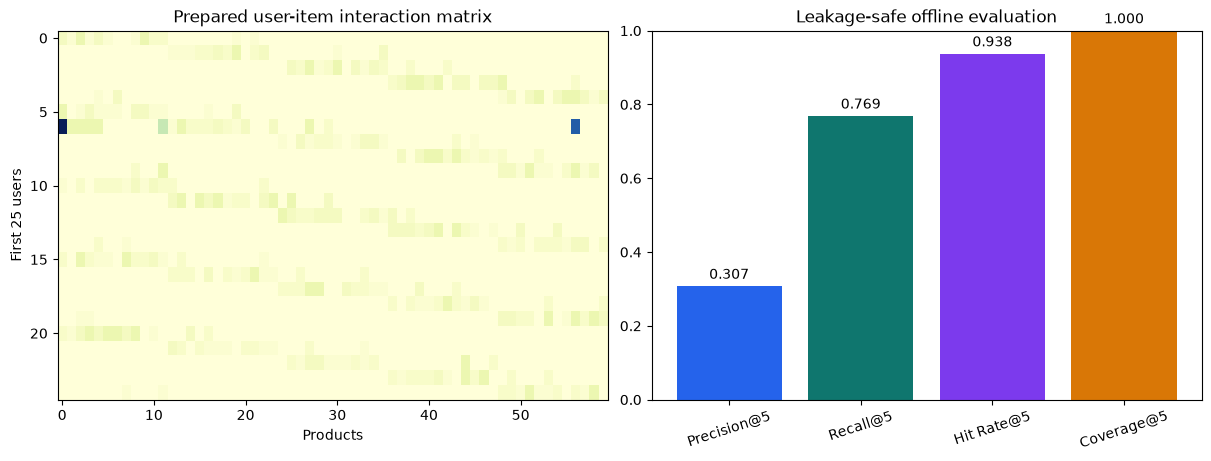

In [4]:

metrics = metadata["metrics"]
metric_names = ["precision_at_k", "recall_at_k", "hit_rate_at_k", "catalogue_coverage_at_k"]
labels = ["Precision@5", "Recall@5", "Hit Rate@5", "Coverage@5"]
values = [metrics[name] for name in metric_names]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].imshow(prepared.matrix[:25], aspect="auto", cmap="YlGnBu")
axes[0].set_title("Prepared user-item interaction matrix")
axes[0].set_xlabel("Products")
axes[0].set_ylabel("First 25 users")
bars = axes[1].bar(labels, values, color=["#2563EB", "#0F766E", "#7C3AED", "#D97706"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Leakage-safe offline evaluation")
axes[1].tick_params(axis="x", rotation=18)
for bar, value in zip(bars, values, strict=True):
    axes[1].text(bar.get_x() + bar.get_width()/2, value + 0.02, f"{value:.3f}", ha="center")
plt.show()



### Reading the offline measures

- **Precision@5** is the share of the five returned products that match the
  held-out set.
- **Recall@5** is the share of held-out products recovered in the ranking.
- **Hit Rate@5** records whether each evaluated user received at least one hit.
- **Coverage@5** is the share of catalogue items that appeared across all
  top-five lists.

These measures let us check the training and ranking path on the seeded data.
They do not estimate CTR or revenue uplift; those require live traffic and an
online experiment.



## 3. Architectural patterns

### Pattern 1 - Microservices

The Command Service and Query Service are separate FastAPI applications with
independent ports and deployment commands. Training/write workloads can scale
separately from latency-sensitive recommendation reads. Streamlit runs as a
third presentation process on port 8501 and calls both service contracts.

### Pattern 2 - CQRS

- **Commands:** `POST /commands/interactions`, `POST /commands/users`, and
  `POST /commands/train`
- **Queries:** recommendations, model info, products, users, and recent actions

The write side produces an immutable, versioned model artifact. The read side
never modifies training data and reloads the artifact when its version changes.
If a named user has no trained row, the read side ranks products from that
profile's selected interest as an explicit cold-start strategy.


### Pattern code: CQRS command/write microservice

```python
"""FastAPI command service: interaction writes and model training."""

from __future__ import annotations

import threading
from datetime import UTC, datetime
from pathlib import Path
from typing import Any
from uuid import uuid4

from fastapi import FastAPI, HTTPException, status

from ecom_ml.api_models import (
    CreateUserCommand,
    InteractionCommand,
    TrainCommand,
    UserCommandResponse,
)
from ecom_ml.config import Settings
from ecom_ml.ml.data import Interaction, append_interaction
from ecom_ml.ml.pipeline import train_pipeline
from ecom_ml.users import append_user, create_user


def create_app(
    *,
    data_path: Path | None = None,
    users_path: Path | None = None,
    artifact_dir: Path | None = None,
) -> FastAPI:
    """Build a command service with injectable paths for testing."""
    settings = Settings.from_env()
    resolved_data = data_path or settings.data_path
    resolved_users = users_path or settings.users_path
    resolved_artifacts = artifact_dir or settings.artifact_dir
    training_lock = threading.Lock()
    application = FastAPI(
        title="SEML Recommendation Command Service",
        version="1.0.0",
        description=(
            "CQRS write side: records implicit-feedback commands and trains "
            "the collaborative-filtering read model."
        ),
    )

    @application.get("/health")
    def health() -> dict[str, str]:
        return {"status": "ok", "service": "command-service", "pattern": "CQRS-command"}

    @application.post("/commands/interactions", status_code=status.HTTP_202_ACCEPTED)
    def record_interaction(command: InteractionCommand) -> dict[str, str]:
        interaction = Interaction(
            event_id=f"cmd-{uuid4().hex}",
            timestamp=command.timestamp or datetime.now(UTC).isoformat(timespec="seconds"),
            user_id=command.user_id,
            item_id=command.item_id,
            action=command.action,
        )
        try:
            append_interaction(resolved_data, interaction)
        except ValueError as exc:
            raise HTTPException(status_code=400, detail=str(exc)) from exc
        return {
            "status": "accepted",
            "event_id": interaction.event_id,
            "pattern": "CQRS-command",
        }

    @application.post(
        "/commands/users",
        response_model=UserCommandResponse,
        status_code=status.HTTP_201_CREATED,
    )
    def add_user(command: CreateUserCommand) -> UserCommandResponse:
        try:
            profile = create_user(command.name, command.interest)
            append_user(resolved_users, profile)
        except ValueError as exc:
            raise HTTPException(status_code=400, detail=str(exc)) from exc
        return UserCommandResponse(
            status="created",
            pattern="CQRS-command",
            user_id=profile.user_id,
            name=profile.name,
            interest=command.interest,
            created_at=profile.created_at,
        )

    @application.post("/commands/train")
    def train(command: TrainCommand) -> dict[str, Any]:
        if not training_lock.acquire(blocking=False):
            raise HTTPException(status_code=409, detail="training is already running")
        try:
            summary = train_pipeline(
                resolved_data,
                resolved_artifacts,
                k=command.k,
                holdout_per_user=command.holdout_per_user,
            )
            return {
                "status": "trained",
                "pattern": "CQRS-command",
                "summary": summary.as_dict(),
            }
        except (FileNotFoundError, ValueError) as exc:
            raise HTTPException(status_code=400, detail=str(exc)) from exc
        finally:
            training_lock.release()

    return application


app = create_app()

```

### Pattern code: CQRS query/read microservice

```python
"""FastAPI query service backed by the latest immutable model artifact."""

from __future__ import annotations

import threading
from pathlib import Path
from typing import Any, cast

from fastapi import FastAPI, HTTPException, Query

from ecom_ml.api_models import (
    Action,
    Interest,
    ProductCatalogResponse,
    ProductInfo,
    RecentAction,
    RecentActionsResponse,
    RecommendationItem,
    RecommendationResponse,
    UserCatalogResponse,
    UserProfileInfo,
)
from ecom_ml.catalog import PRODUCTS, get_product
from ecom_ml.config import Settings
from ecom_ml.ml.artifact import METADATA_FILENAME, load_artifact
from ecom_ml.ml.data import load_interactions
from ecom_ml.ml.model import CollaborativeFilteringModel
from ecom_ml.users import load_users


class ModelRepository:
    """Thread-safe, mtime-aware cache of the CQRS read model."""

    def __init__(self, artifact_dir: Path) -> None:
        self._artifact_dir = artifact_dir
        self._lock = threading.RLock()
        self._model: CollaborativeFilteringModel | None = None
        self._metadata: dict[str, Any] | None = None
        self._metadata_mtime_ns = -1

    def get(self) -> tuple[CollaborativeFilteringModel, dict[str, Any]]:
        metadata_path = self._artifact_dir / METADATA_FILENAME
        if not metadata_path.exists():
            raise FileNotFoundError("no trained model; run the training command first")
        current_mtime = metadata_path.stat().st_mtime_ns
        with self._lock:
            if self._model is None or current_mtime != self._metadata_mtime_ns:
                self._model, self._metadata = load_artifact(self._artifact_dir)
                self._metadata_mtime_ns = current_mtime
            assert self._metadata is not None
            return self._model, dict(self._metadata)


def create_app(
    *,
    artifact_dir: Path | None = None,
    data_path: Path | None = None,
    users_path: Path | None = None,
) -> FastAPI:
    """Build a query service with an injectable artifact location."""
    settings = Settings.from_env()
    repository = ModelRepository(artifact_dir or settings.artifact_dir)
    resolved_data = data_path or settings.data_path
    resolved_users = users_path or settings.users_path
    application = FastAPI(
        title="SEML Recommendation Query Service",
        version="1.0.0",
        description=(
            "CQRS read side: independently serves low-latency recommendations "
            "from a versioned collaborative-filtering model."
        ),
    )

    @application.get("/health")
    def health() -> dict[str, str]:
        try:
            model, _ = repository.get()
        except (FileNotFoundError, ValueError):
            return {"status": "not_ready", "service": "query-service", "pattern": "CQRS-query"}
        return {
            "status": "ok",
            "service": "query-service",
            "pattern": "CQRS-query",
            "model_version": model.version,
        }

    @application.get("/queries/model-info")
    def model_info() -> dict[str, Any]:
        try:
            _, metadata = repository.get()
        except (FileNotFoundError, ValueError) as exc:
            raise HTTPException(status_code=503, detail=str(exc)) from exc
        return {"pattern": "CQRS-query", **metadata}

    @application.get("/queries/products", response_model=ProductCatalogResponse)
    def products() -> ProductCatalogResponse:
        return ProductCatalogResponse(
            products=[
                ProductInfo(
                    item_id=product.item_id,
                    product_name=product.name,
                    category=product.category,
                )
                for product in PRODUCTS
            ]
        )

    @application.get("/queries/users", response_model=UserCatalogResponse)
    def users() -> UserCatalogResponse:
        try:
            profiles = load_users(resolved_users)
        except (FileNotFoundError, ValueError) as exc:
            raise HTTPException(status_code=503, detail=str(exc)) from exc
        return UserCatalogResponse(
            users=[
                UserProfileInfo(
                    user_id=profile.user_id,
                    name=profile.name,
                    interest=cast(Interest, profile.interest),
                    created_at=profile.created_at,
                )
                for profile in profiles
            ]
        )

    @application.get("/queries/recent-actions", response_model=RecentActionsResponse)
    def recent_actions(
        user_id: str = Query(min_length=1),
        limit: int = Query(default=3, ge=1, le=10),
    ) -> RecentActionsResponse:
        try:
            rows = load_interactions(resolved_data)
        except (FileNotFoundError, ValueError) as exc:
            raise HTTPException(status_code=503, detail=str(exc)) from exc

        selected = [row for row in reversed(rows) if row.user_id == user_id][:limit]
        actions: list[RecentAction] = []
        for row in selected:
            product = get_product(row.item_id)
            actions.append(
                RecentAction(
                    event_id=row.event_id,
                    timestamp=row.timestamp,
                    user_id=row.user_id,
                    item_id=row.item_id,
                    product_name=product.name,
                    category=product.category,
                    action=cast(Action, row.action),
                )
            )
        try:
            profiles = load_users(resolved_users)
        except (FileNotFoundError, ValueError):
            profiles = []
        profile = next((profile for profile in profiles if profile.user_id == user_id), None)
        interest = cast(Interest, profile.interest) if profile is not None else None
        return RecentActionsResponse(user_id=user_id, interest=interest, actions=actions)

    @application.get("/queries/recommendations", response_model=RecommendationResponse)
    def recommendations(
        user_id: str = Query(min_length=1),
        k: int = Query(default=5, ge=1, le=20),
    ) -> RecommendationResponse:
        try:
            model, _ = repository.get()
        except (FileNotFoundError, ValueError) as exc:
            raise HTTPException(status_code=503, detail=str(exc)) from exc

        recommendation_items: list[RecommendationItem] = []
        strategy = "item-based-collaborative-filtering"
        if user_id in model.users:
            ranked = model.recommend(user_id, k)
            for recommendation in ranked:
                product = get_product(recommendation.item_id)
                recommendation_items.append(
                    RecommendationItem(
                        item_id=recommendation.item_id,
                        product_name=product.name,
                        category=product.category,
                        score=recommendation.score,
                    )
                )
        else:
            try:
                profiles = load_users(resolved_users)
            except (FileNotFoundError, ValueError) as exc:
                raise HTTPException(status_code=503, detail=str(exc)) from exc
            profile = next((profile for profile in profiles if profile.user_id == user_id), None)
            if profile is None:
                raise HTTPException(status_code=404, detail=f"unknown user: {user_id}")

            preferred_products = [
                product for product in PRODUCTS if product.category == profile.interest
            ][:k]
            recommendation_items = [
                RecommendationItem(
                    item_id=product.item_id,
                    product_name=product.name,
                    category=product.category,
                    score=round(1.0 - (index * 0.05), 4),
                )
                for index, product in enumerate(preferred_products)
            ]
            strategy = "interest-based-cold-start"

        return RecommendationResponse(
            user_id=user_id,
            model_version=model.version,
            strategy=strategy,
            recommendations=recommendation_items,
        )

    return application


app = create_app()

```

### User profiles and default-interest persistence

```python
"""Persistent user profiles used for named users and cold-start interests."""

from __future__ import annotations

import csv
import re
import threading
from dataclasses import dataclass
from datetime import UTC, datetime
from pathlib import Path
from typing import Final
from uuid import uuid4

from ecom_ml.catalog import CATEGORIES

USER_FIELDS: Final[tuple[str, ...]] = ("user_id", "name", "interest", "created_at")
DEFAULT_USER_SPECS: Final[tuple[tuple[str, str, str], ...]] = (
    ("u001", "Shreyas", "Electronics"),
    ("u002", "Sumanth", "Home & Kitchen"),
    ("u003", "Ravi", "Fashion"),
    ("u004", "Vivek", "Personal Care"),
    ("u005", "Nishant", "Fitness & Lifestyle"),
)
_WRITE_LOCK = threading.Lock()


@dataclass(frozen=True, slots=True)
class UserProfile:
    """One named customer profile with a cold-start interest."""

    user_id: str
    name: str
    interest: str
    created_at: str

    def as_csv_row(self) -> dict[str, str]:
        return {
            "user_id": self.user_id,
            "name": self.name,
            "interest": self.interest,
            "created_at": self.created_at,
        }


def generate_default_users(path: Path) -> list[UserProfile]:
    """Write the five deterministic demonstration user profiles."""
    profiles = [
        UserProfile(
            user_id=user_id,
            name=name,
            interest=interest,
            created_at="2026-01-01T09:00:00+00:00",
        )
        for user_id, name, interest in DEFAULT_USER_SPECS
    ]
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(USER_FIELDS))
        writer.writeheader()
        writer.writerows(profile.as_csv_row() for profile in profiles)
    return profiles


def load_users(path: Path) -> list[UserProfile]:
    """Load and validate user profiles from the profile store."""
    if not path.exists():
        raise FileNotFoundError(f"user profile store not found: {path}")

    with path.open(encoding="utf-8", newline="") as handle:
        reader = csv.DictReader(handle)
        if reader.fieldnames is None or not set(USER_FIELDS).issubset(reader.fieldnames):
            raise ValueError(f"user profile store must contain: {', '.join(USER_FIELDS)}")
        profiles = [
            UserProfile(
                user_id=(row["user_id"] or "").strip(),
                name=(row["name"] or "").strip(),
                interest=(row["interest"] or "").strip(),
                created_at=(row["created_at"] or "").strip(),
            )
            for row in reader
        ]
    for profile in profiles:
        validate_user(profile)
    return profiles


def create_user(name: str, interest: str) -> UserProfile:
    """Create a validated profile with a readable collision-resistant ID."""
    cleaned_name = name.strip()
    slug = re.sub(r"[^a-z0-9]+", "-", cleaned_name.lower()).strip("-") or "user"
    profile = UserProfile(
        user_id=f"usr-{slug}-{uuid4().hex[:6]}",
        name=cleaned_name,
        interest=interest.strip(),
        created_at=datetime.now(UTC).isoformat(timespec="seconds"),
    )
    validate_user(profile)
    return profile


def append_user(path: Path, profile: UserProfile) -> None:
    """Append one user profile after validating uniqueness and fields."""
    validate_user(profile)
    path.parent.mkdir(parents=True, exist_ok=True)
    with _WRITE_LOCK:
        existing = load_users(path) if path.exists() else []
        if any(user.user_id == profile.user_id for user in existing):
            raise ValueError(f"user ID already exists: {profile.user_id}")
        needs_header = not path.exists() or path.stat().st_size == 0
        with path.open("a", encoding="utf-8", newline="") as handle:
            writer = csv.DictWriter(handle, fieldnames=list(USER_FIELDS))
            if needs_header:
                writer.writeheader()
            writer.writerow(profile.as_csv_row())


def validate_user(profile: UserProfile) -> None:
    """Validate profile fields shared by loading and command ingestion."""
    if not profile.user_id:
        raise ValueError("user_id is required")
    if not profile.name:
        raise ValueError("name is required")
    if profile.interest not in CATEGORIES:
        raise ValueError(f"interest must be one of: {', '.join(CATEGORIES)}")
    try:
        datetime.fromisoformat(profile.created_at)
    except ValueError as exc:
        raise ValueError("created_at must be ISO-8601") from exc

```


## 4. GR4ML views and cross-view traceability

The three diagrams use one visual style: the same title treatment, type scale,
line weight, spacing, and footer key. The shapes retain their GR4ML meaning:

- **Business View:** stick-figure Actor, oval Business Goal, D-marked Decision
  Goal, Q-marked Question Goal, traffic-light Indicator, and structured Insight.
- **Analytics Design View:** oval Analytics Goal, hexagonal Algorithm,
  cloud-shaped Softgoal, traffic-light Indicator, and the Performs, Evaluates,
  Generates, Association, and Influence links.
- **Data Preparation View:** structured Entity, rectangular Operator,
  folded-corner Note, solid Data Flow, dashed Input/Output, and Relationship.

The trace across the views is:

`Prepared User-Item Matrix` **is required for** the Prediction and Ranking
Analytics Goal -> the goal **generates** the Top-5 Recommendation Insight ->
the insight **answers** the Question Goal -> the answer supports the product
Decision Goal -> the decision contributes to the revenue Business Goal.


GR4ML Business View


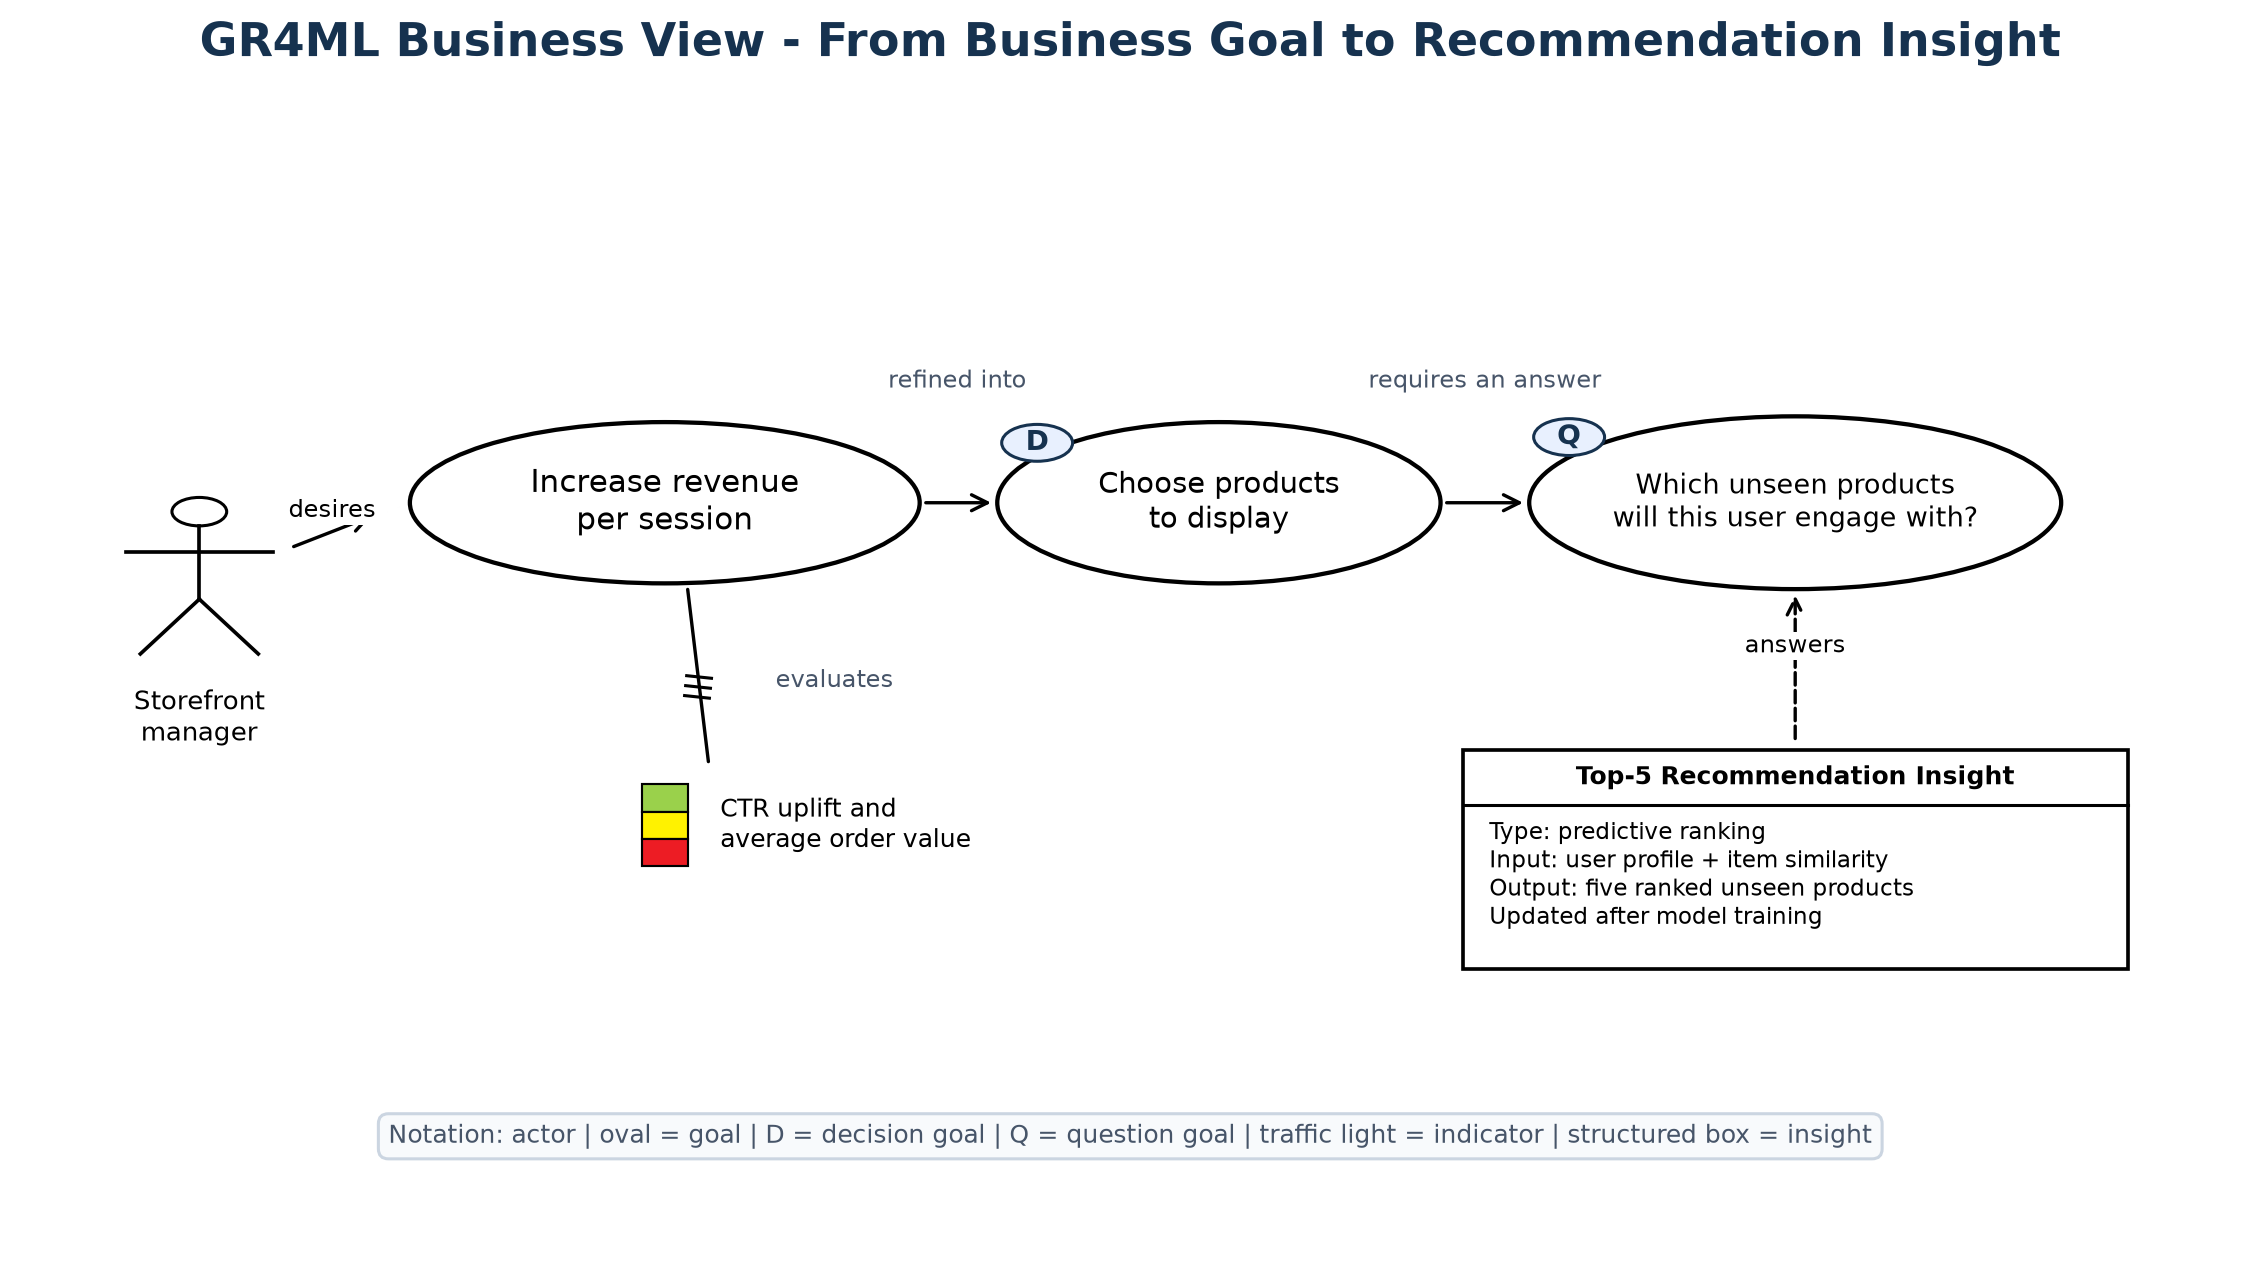

GR4ML Analytics Design View


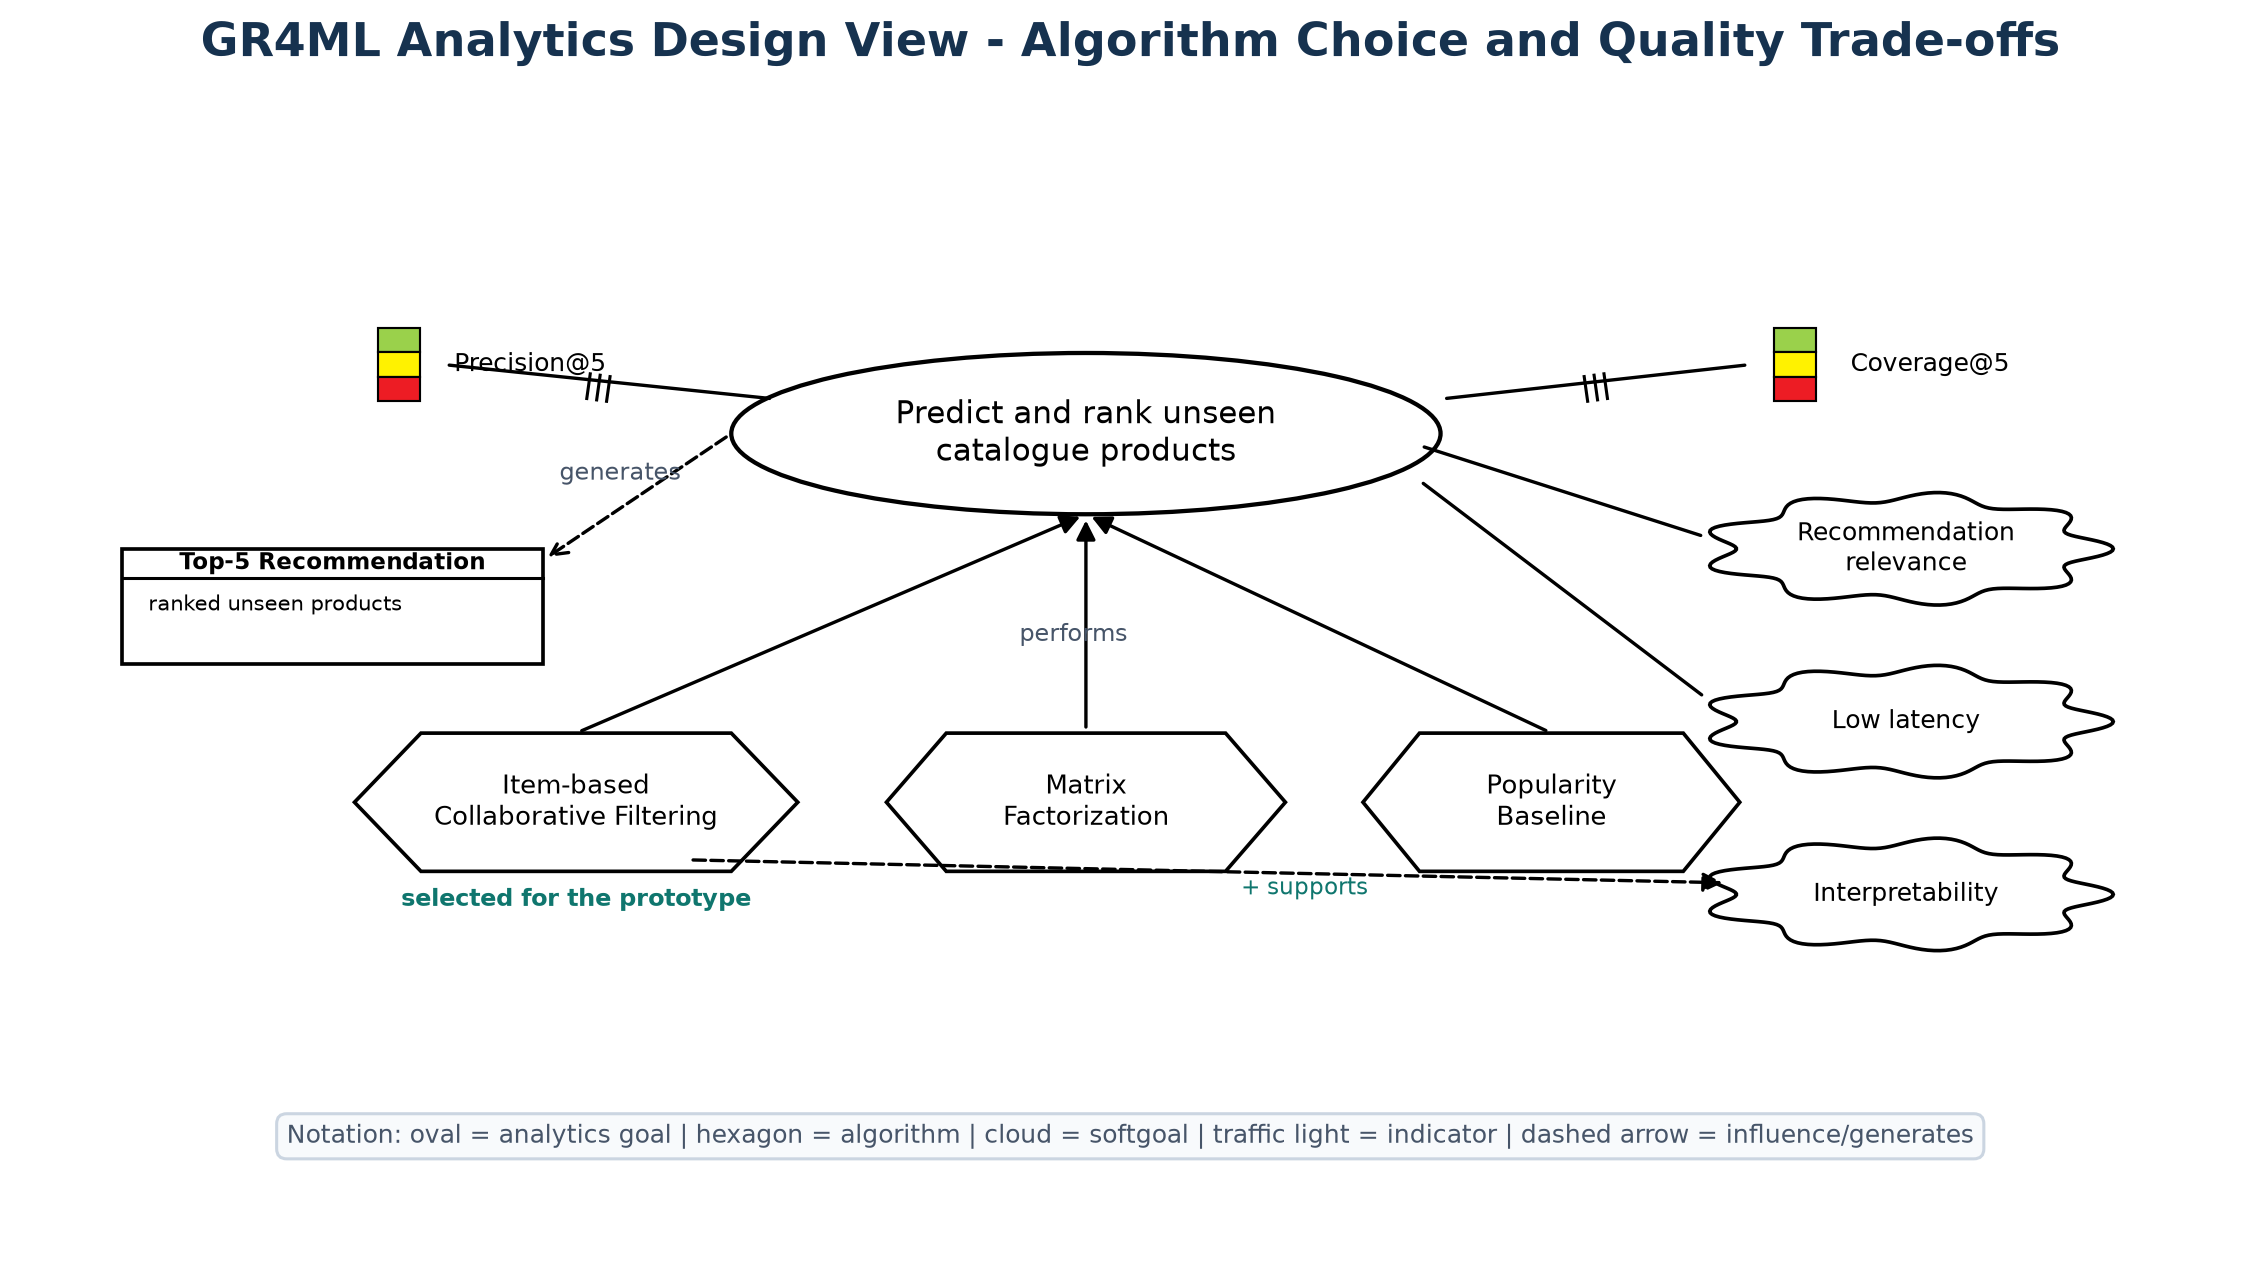

GR4ML Data Preparation View


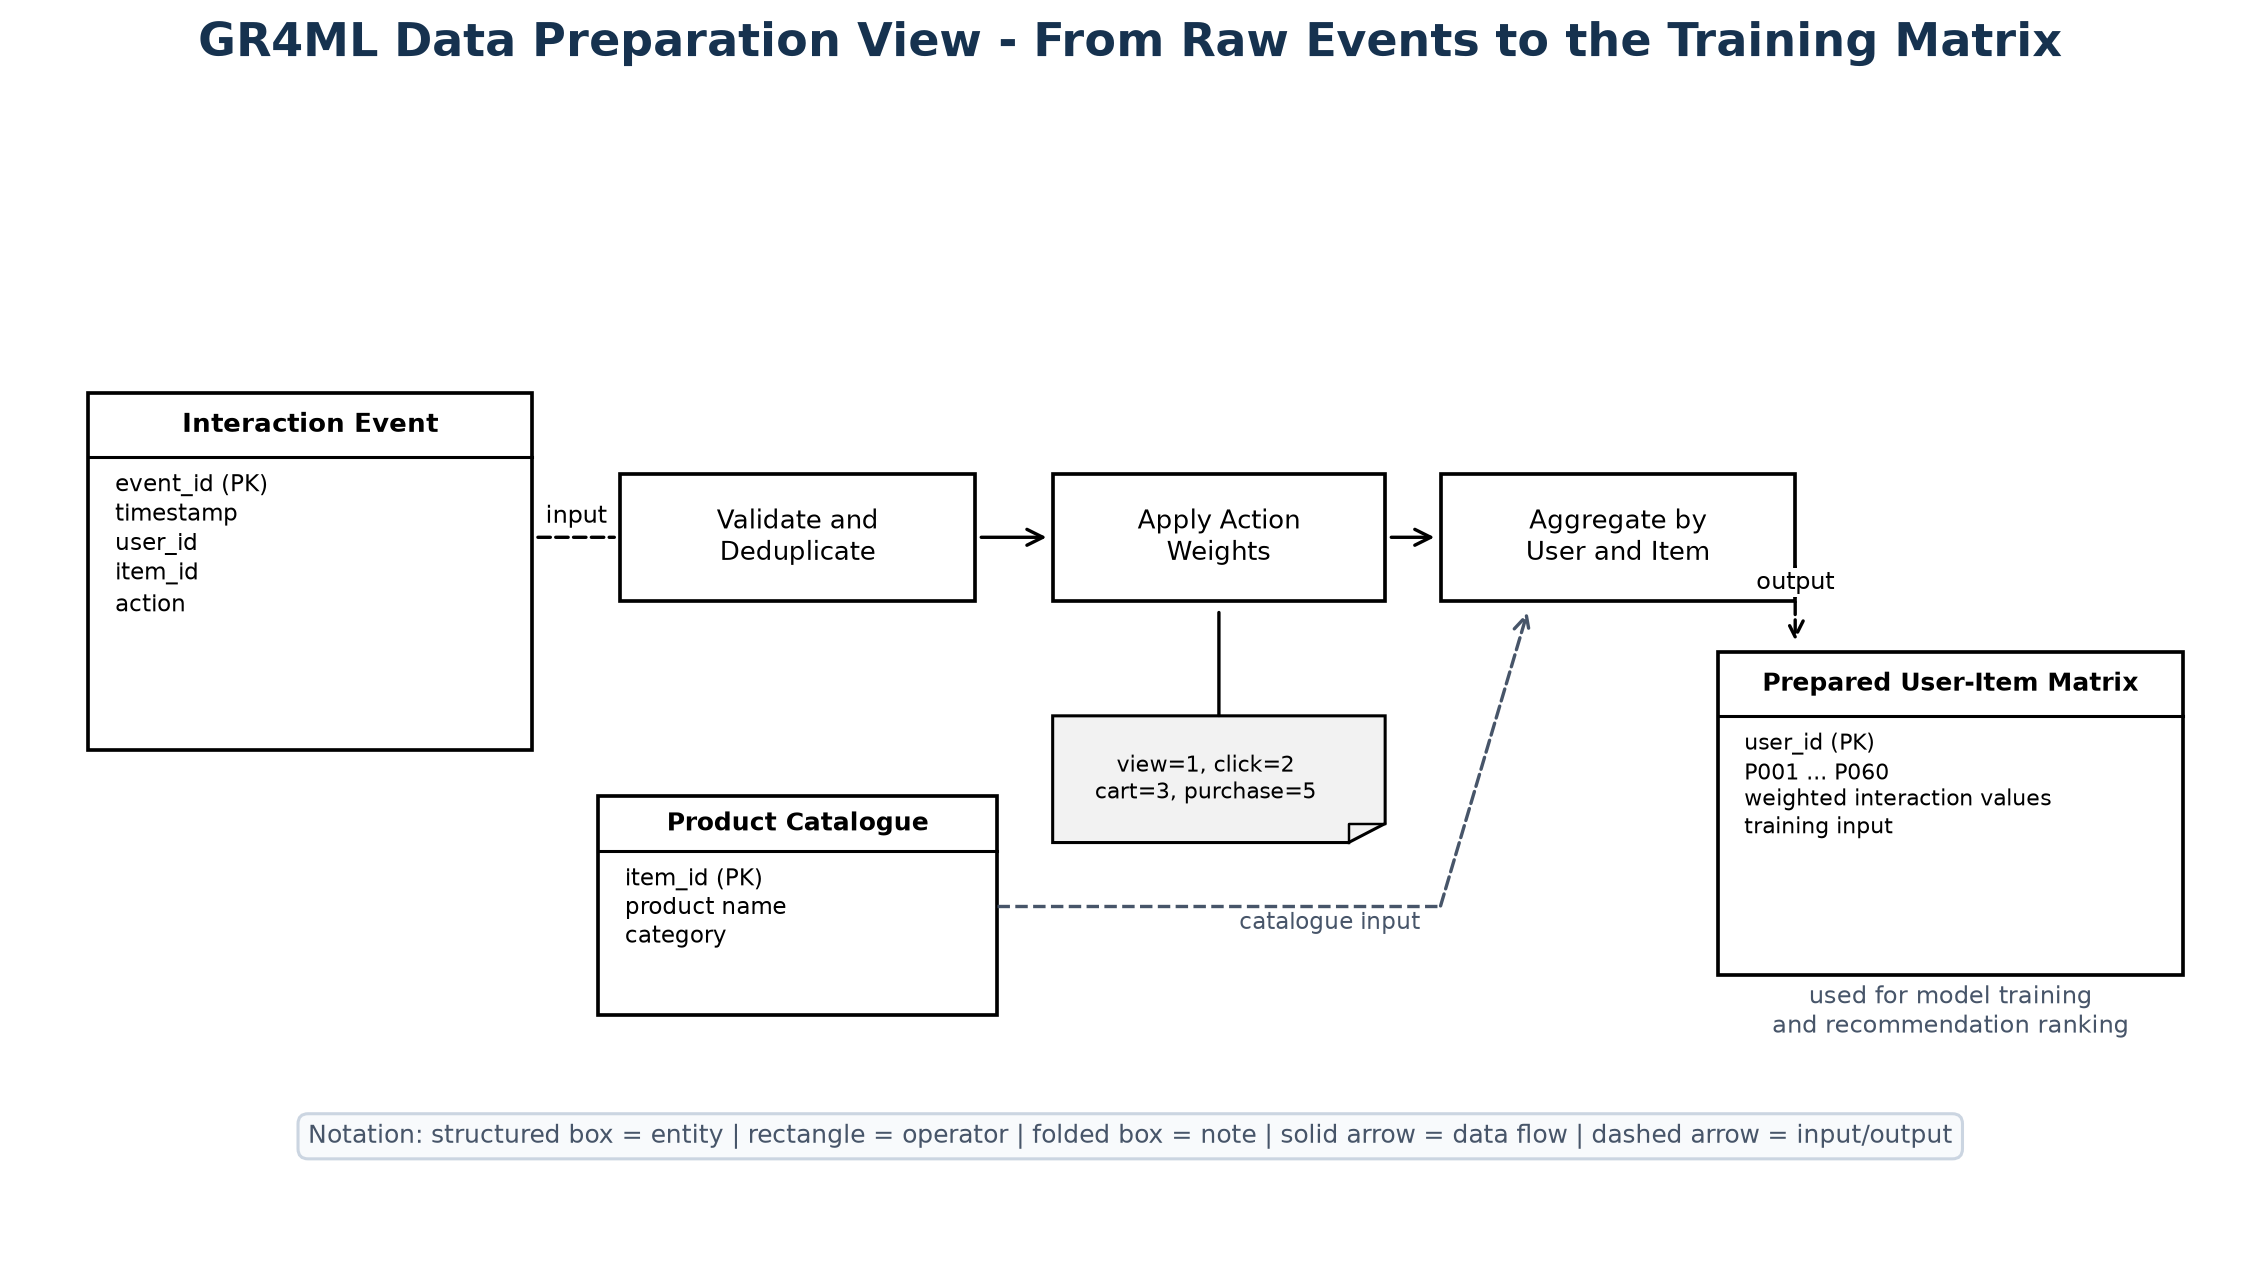

System Architecture


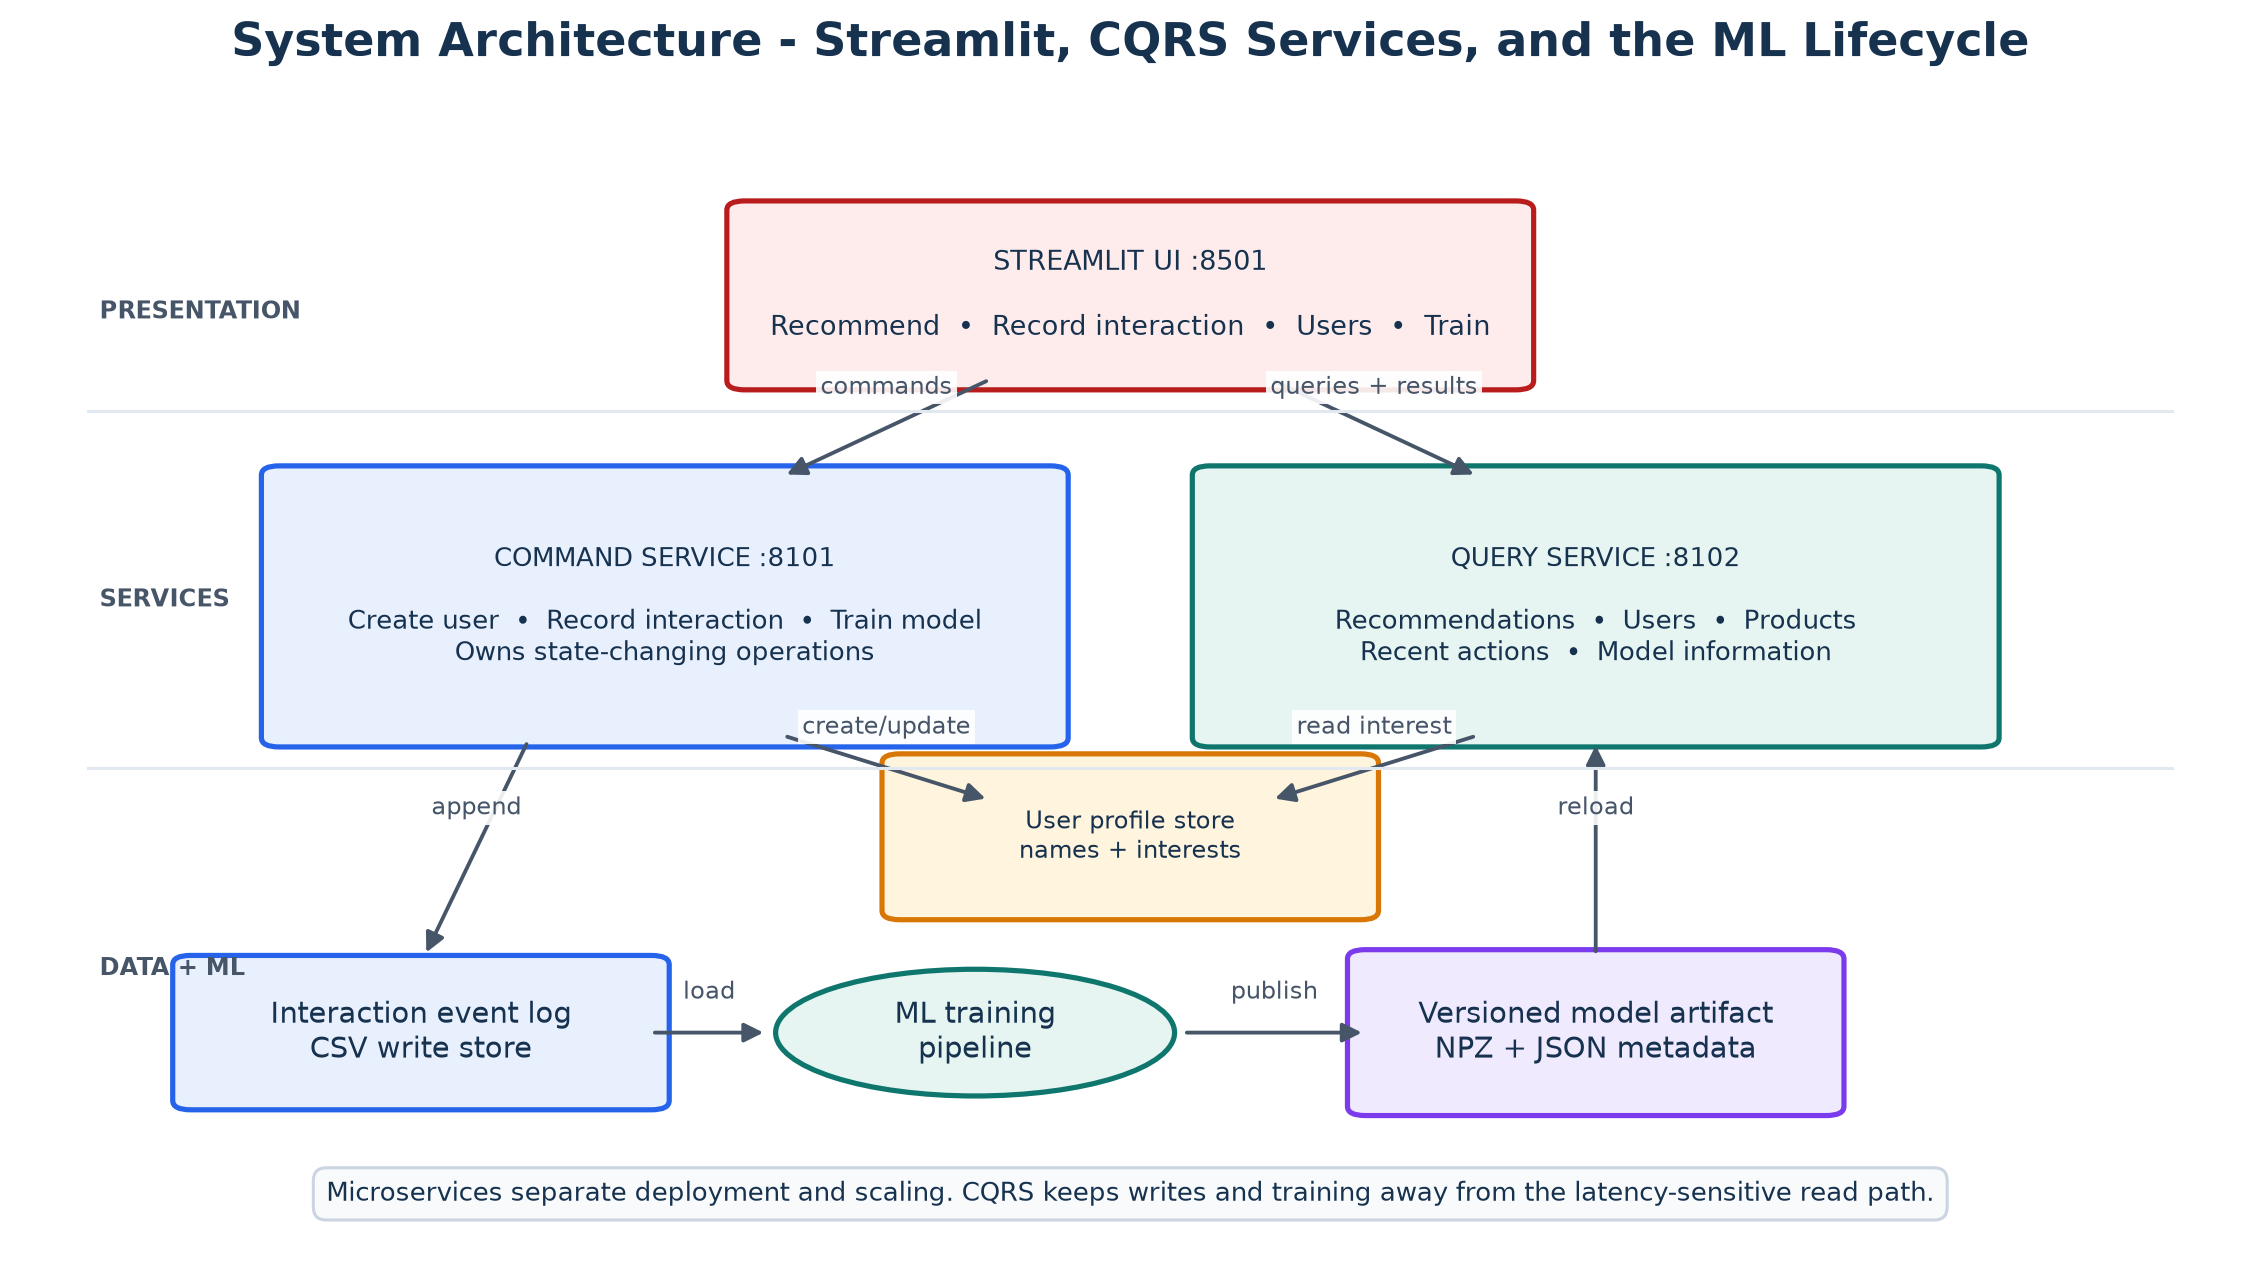

In [5]:

from IPython.display import Image, display

visuals = [
    ("GR4ML Business View", ROOT / "evidence" / "gr4ml_business_view.png"),
    ("GR4ML Analytics Design View", ROOT / "evidence" / "gr4ml_analytics_design_view.png"),
    ("GR4ML Data Preparation View", ROOT / "evidence" / "gr4ml_data_preparation_view.png"),
    ("System Architecture", ROOT / "evidence" / "system_architecture.png"),
]
for title, path in visuals:
    print(title)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print("Generate with: python tools/generate_assets.py")



## 5. Application flows captured in the browser

The captures in this section come from the running Swagger and Streamlit pages.
They record an isolated demonstration dataset. The Command Service used port
8111 during capture to keep that dataset separate; the normal Makefile and
architecture port remains 8101. Model version identifiers change each time a
new artifact is published.

1. **Command API:** Swagger exposes profile creation, interaction ingestion,
   training, and health on the write side.
2. **Query API:** Swagger exposes products, named users, recent actions, model
   metadata, and recommendations without command routes.
3. **Recommendation flow:** select a named user and top-k value; receive named
   products, categories, scores, strategy, and the latest three actions.
4. **Interaction flow:** select customer, product, and action; append a
   validated implicit-feedback command.
5. **User flow:** review the five defaults and create a profile with a primary
   interest.
6. **Cold-start flow:** a new user receives products from the selected interest
   and sees the explicit no-history explanation.
7. **Training flow:** configure K and holdout values, run the five-stage
   pipeline, and publish a refreshed read model. The captured run contains 961
   events because the interaction flow added one click to the 960-event seed.


Command Service Swagger UI


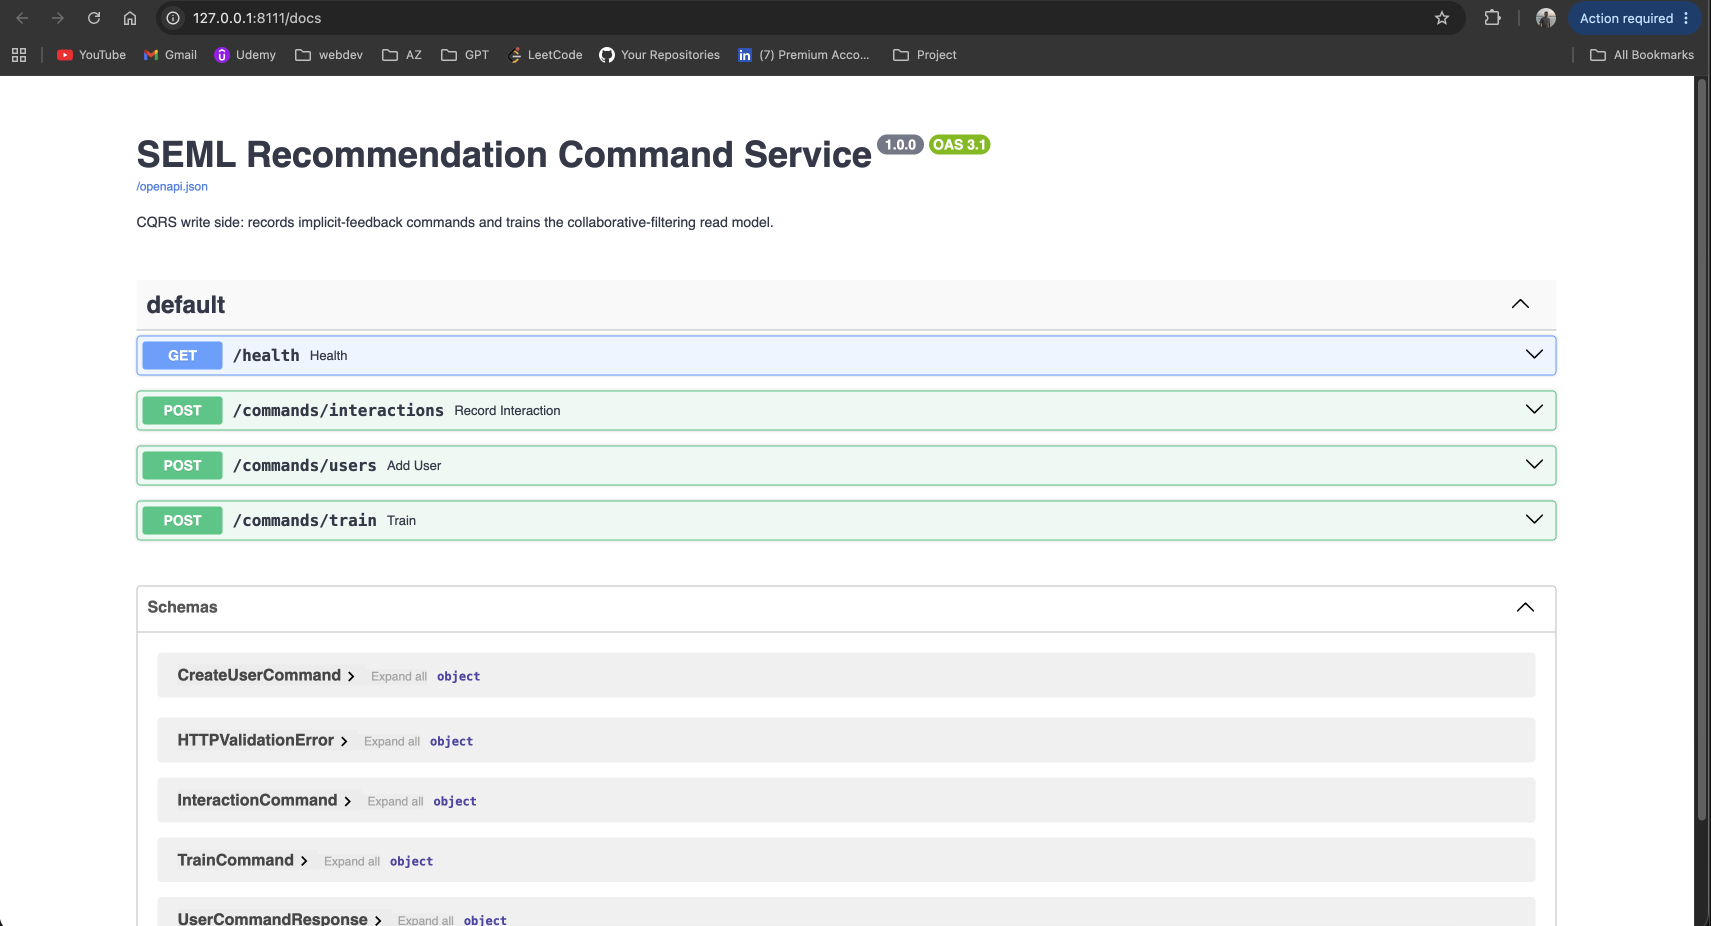

Query Service Swagger UI


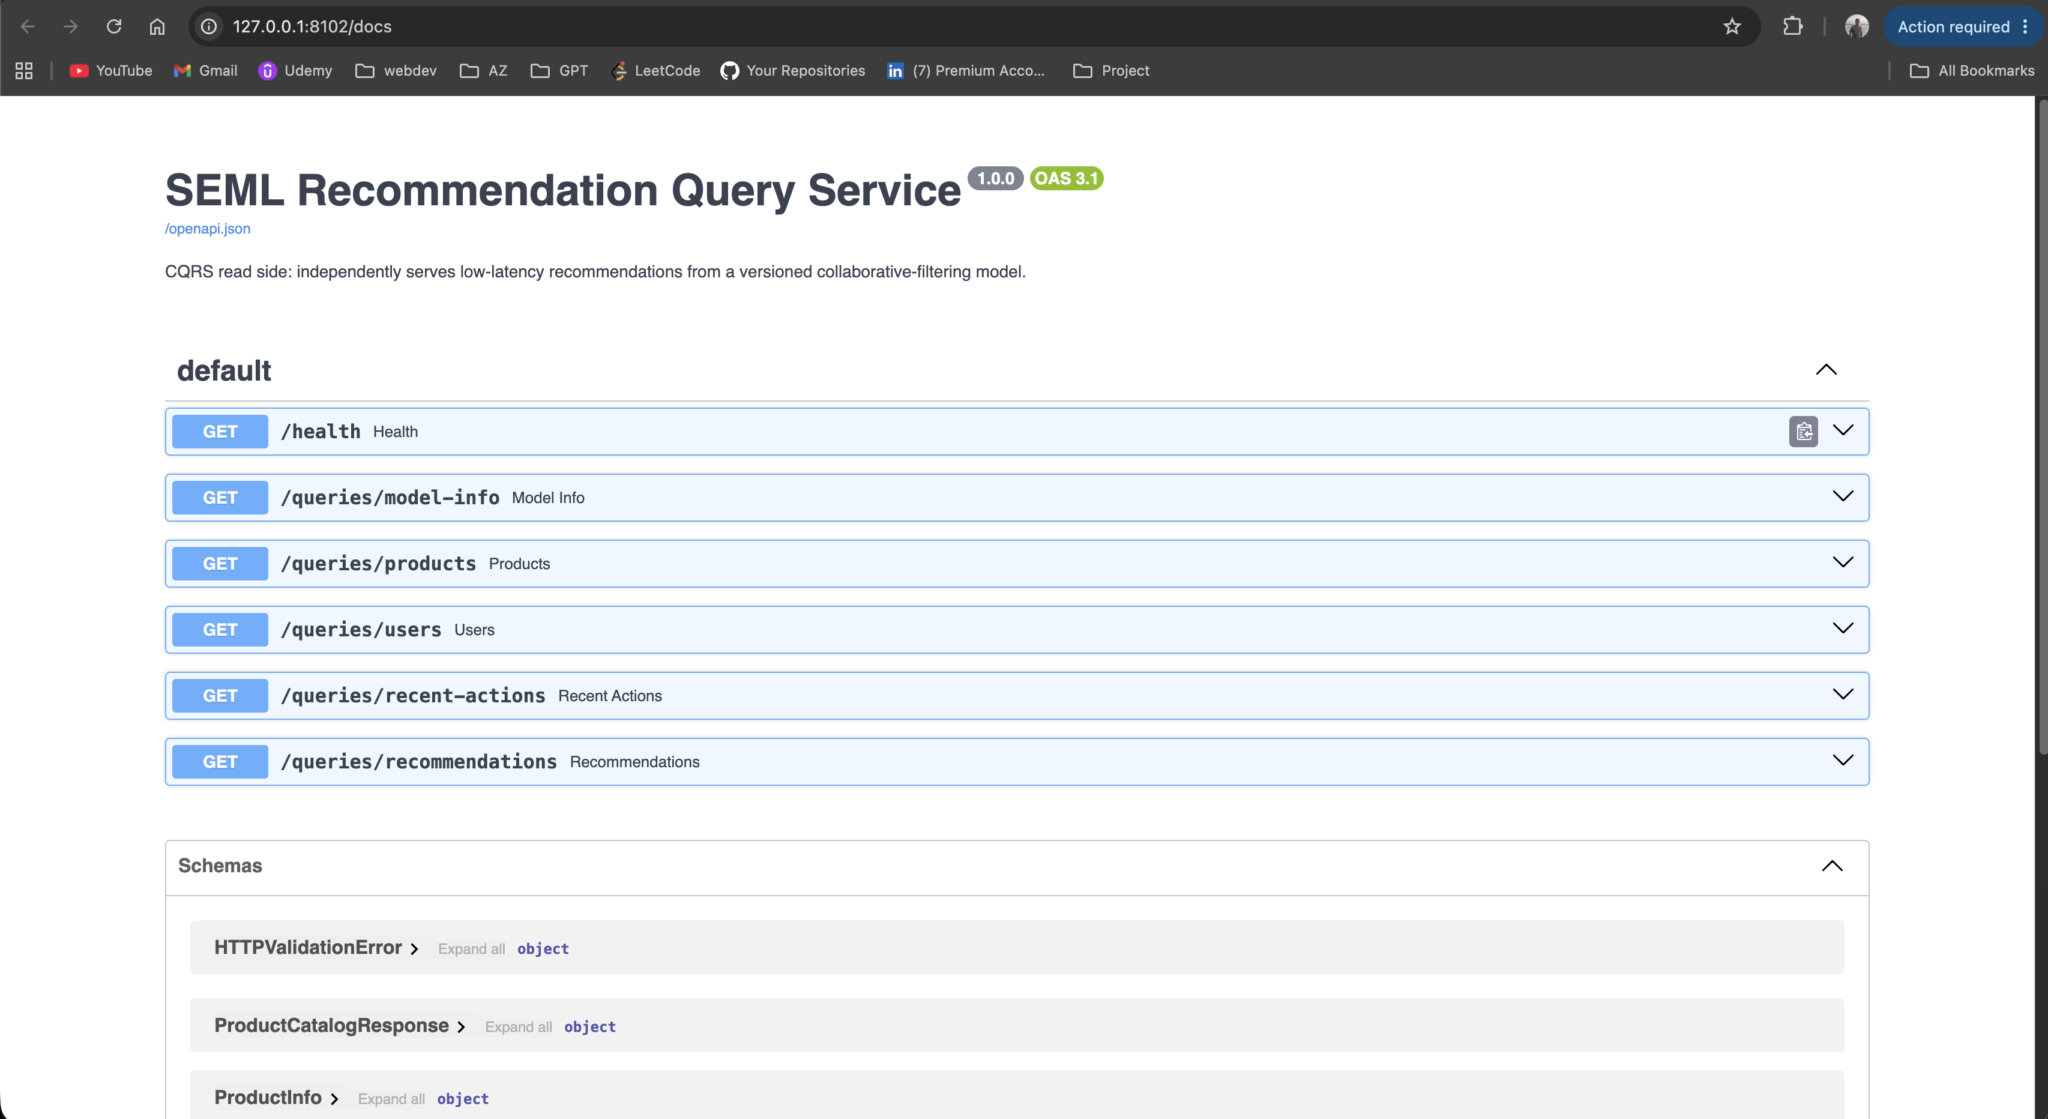

Recommendation and recent-action flow


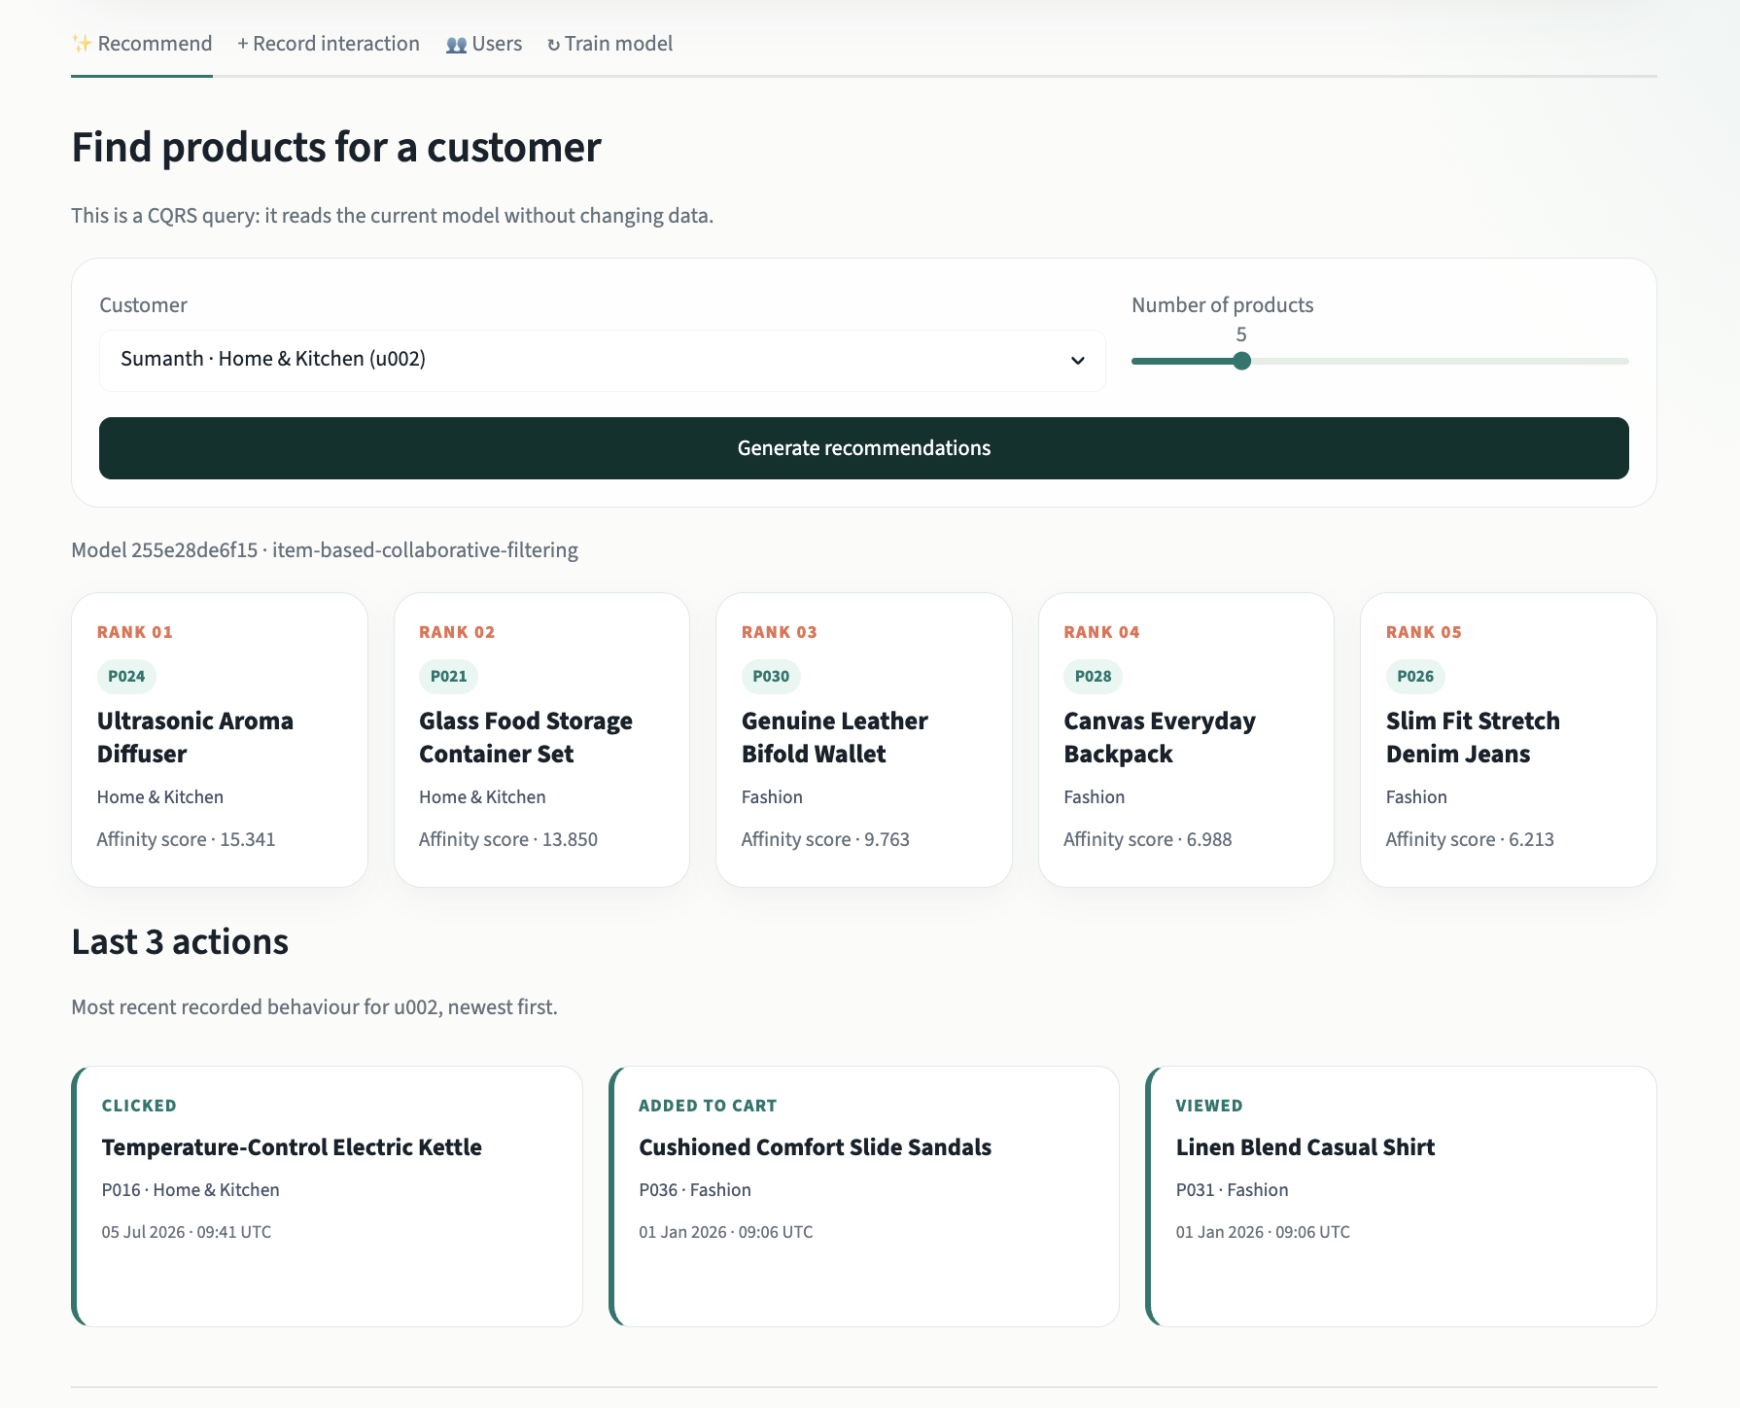

Interaction command flow


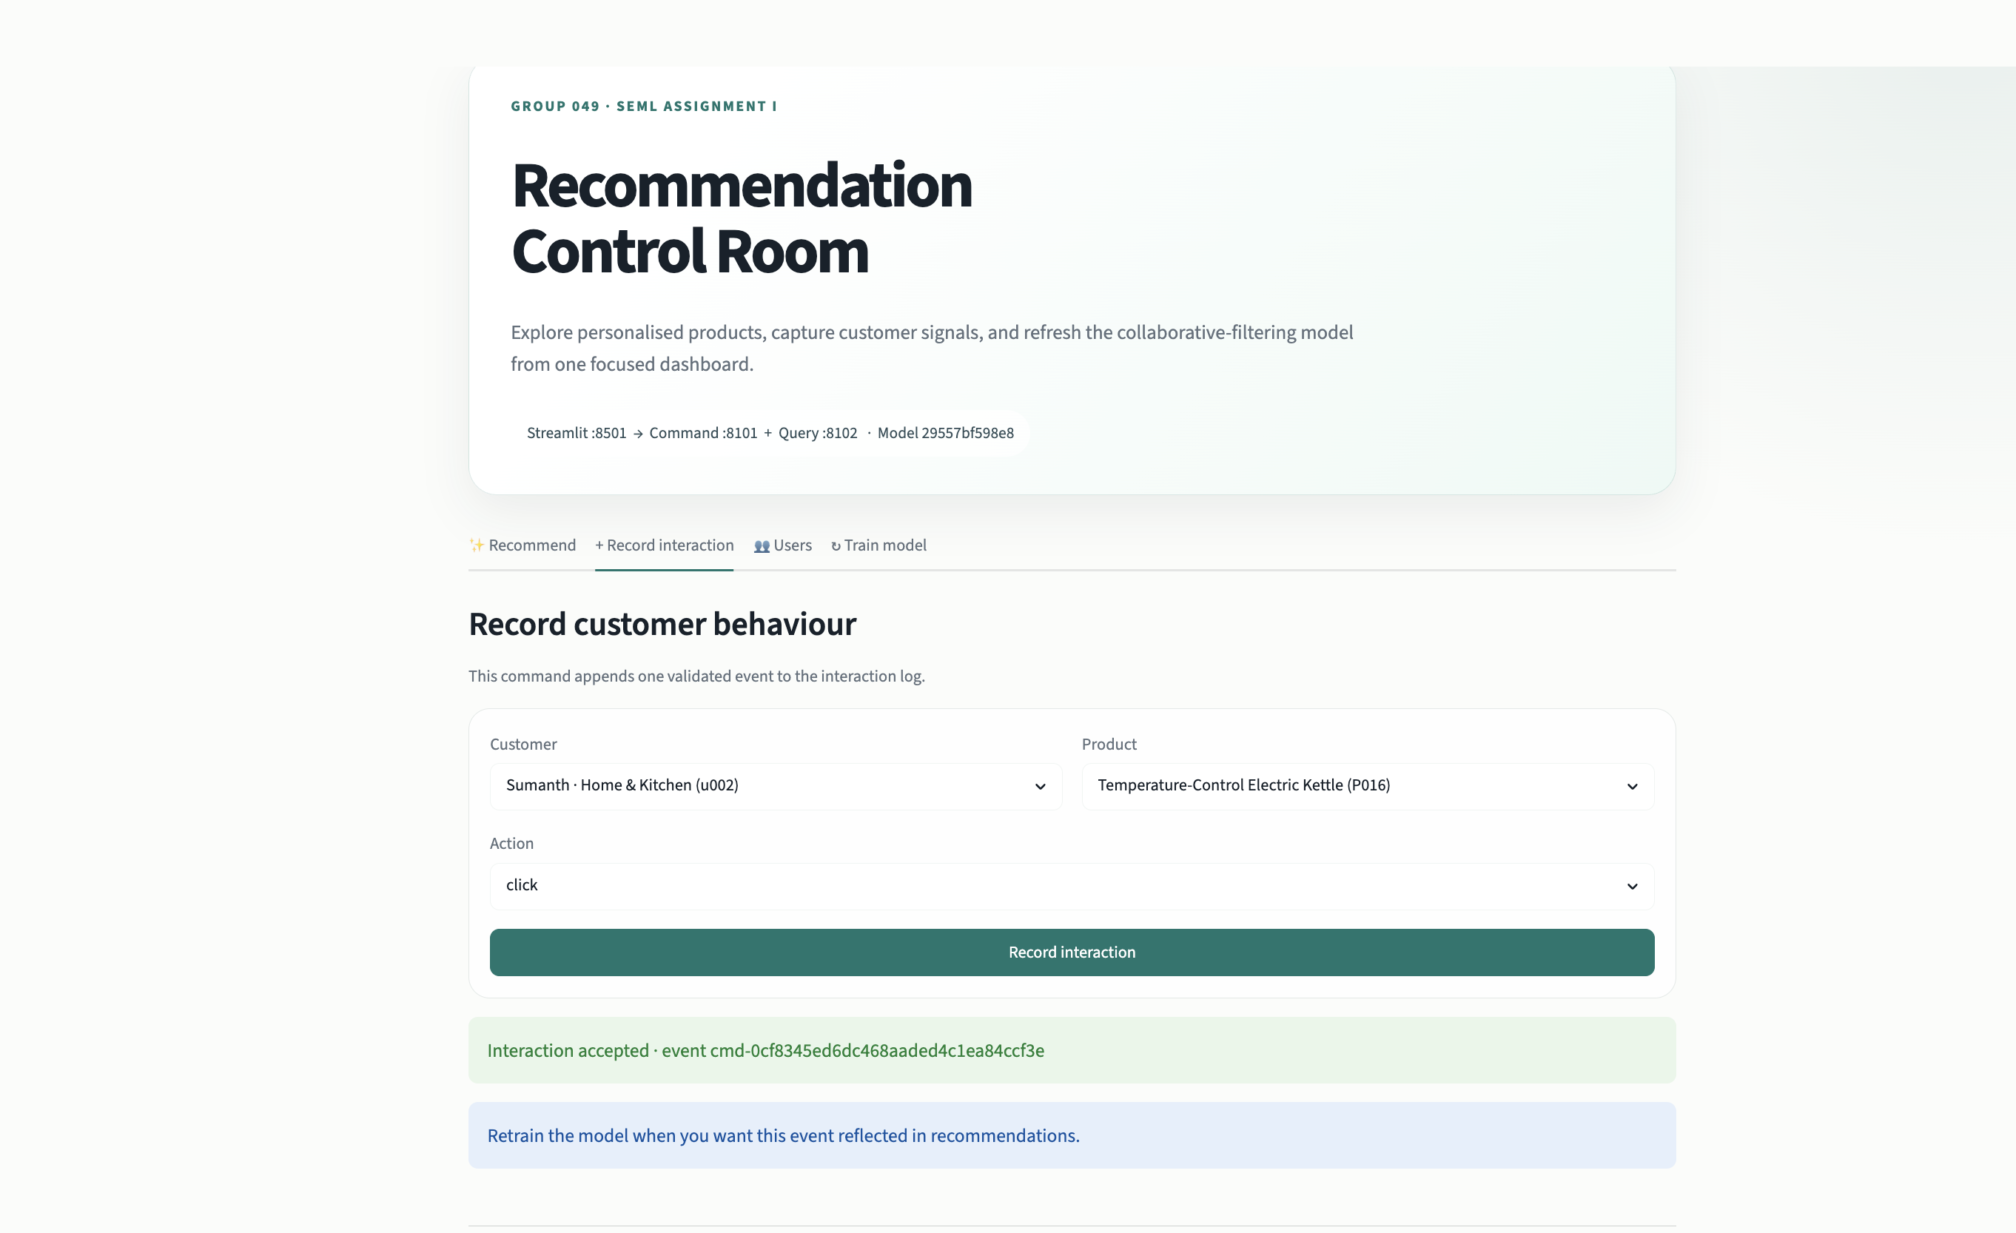

Named-user management flow


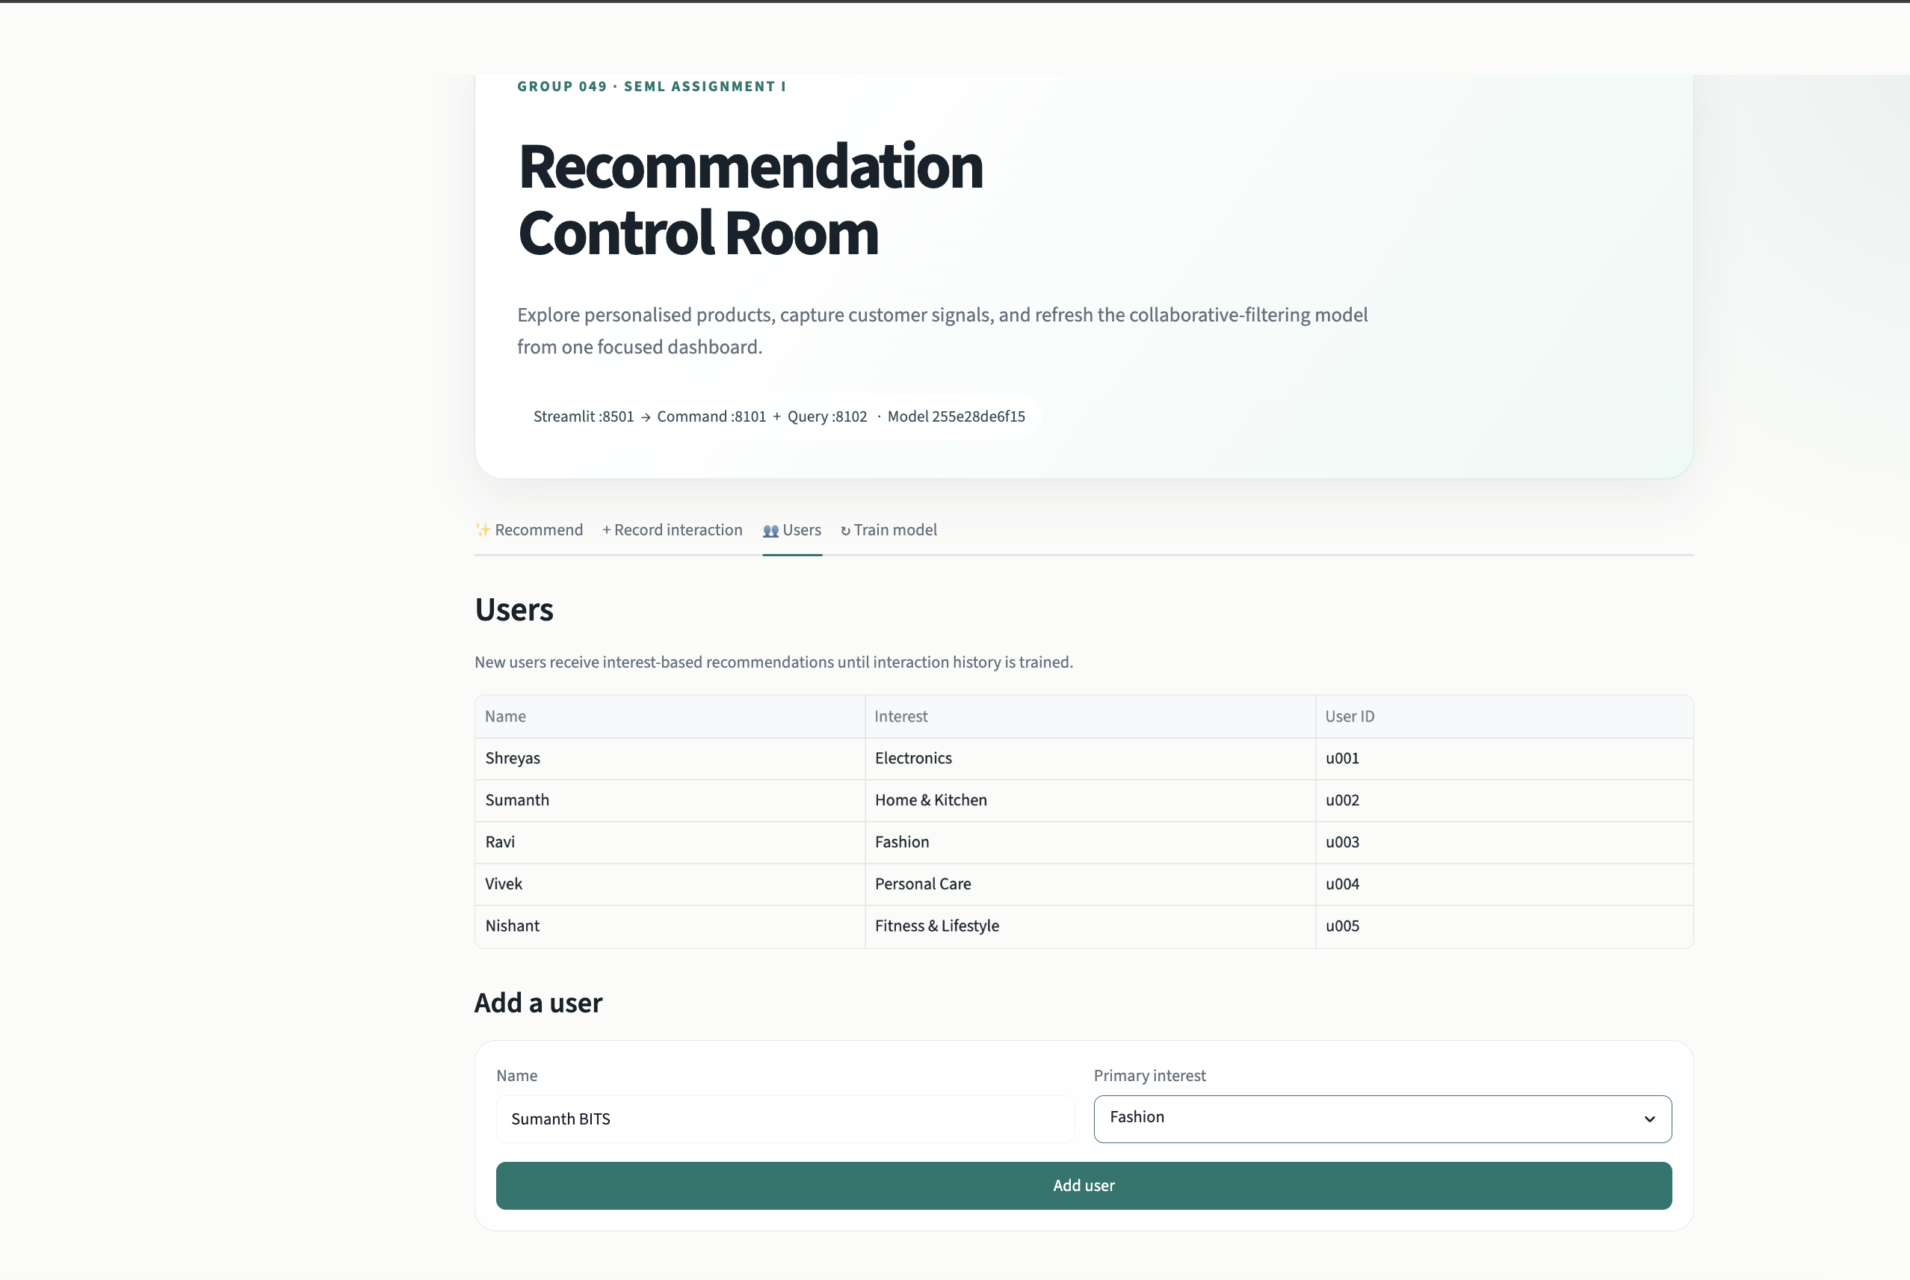

Interest-based cold-start flow


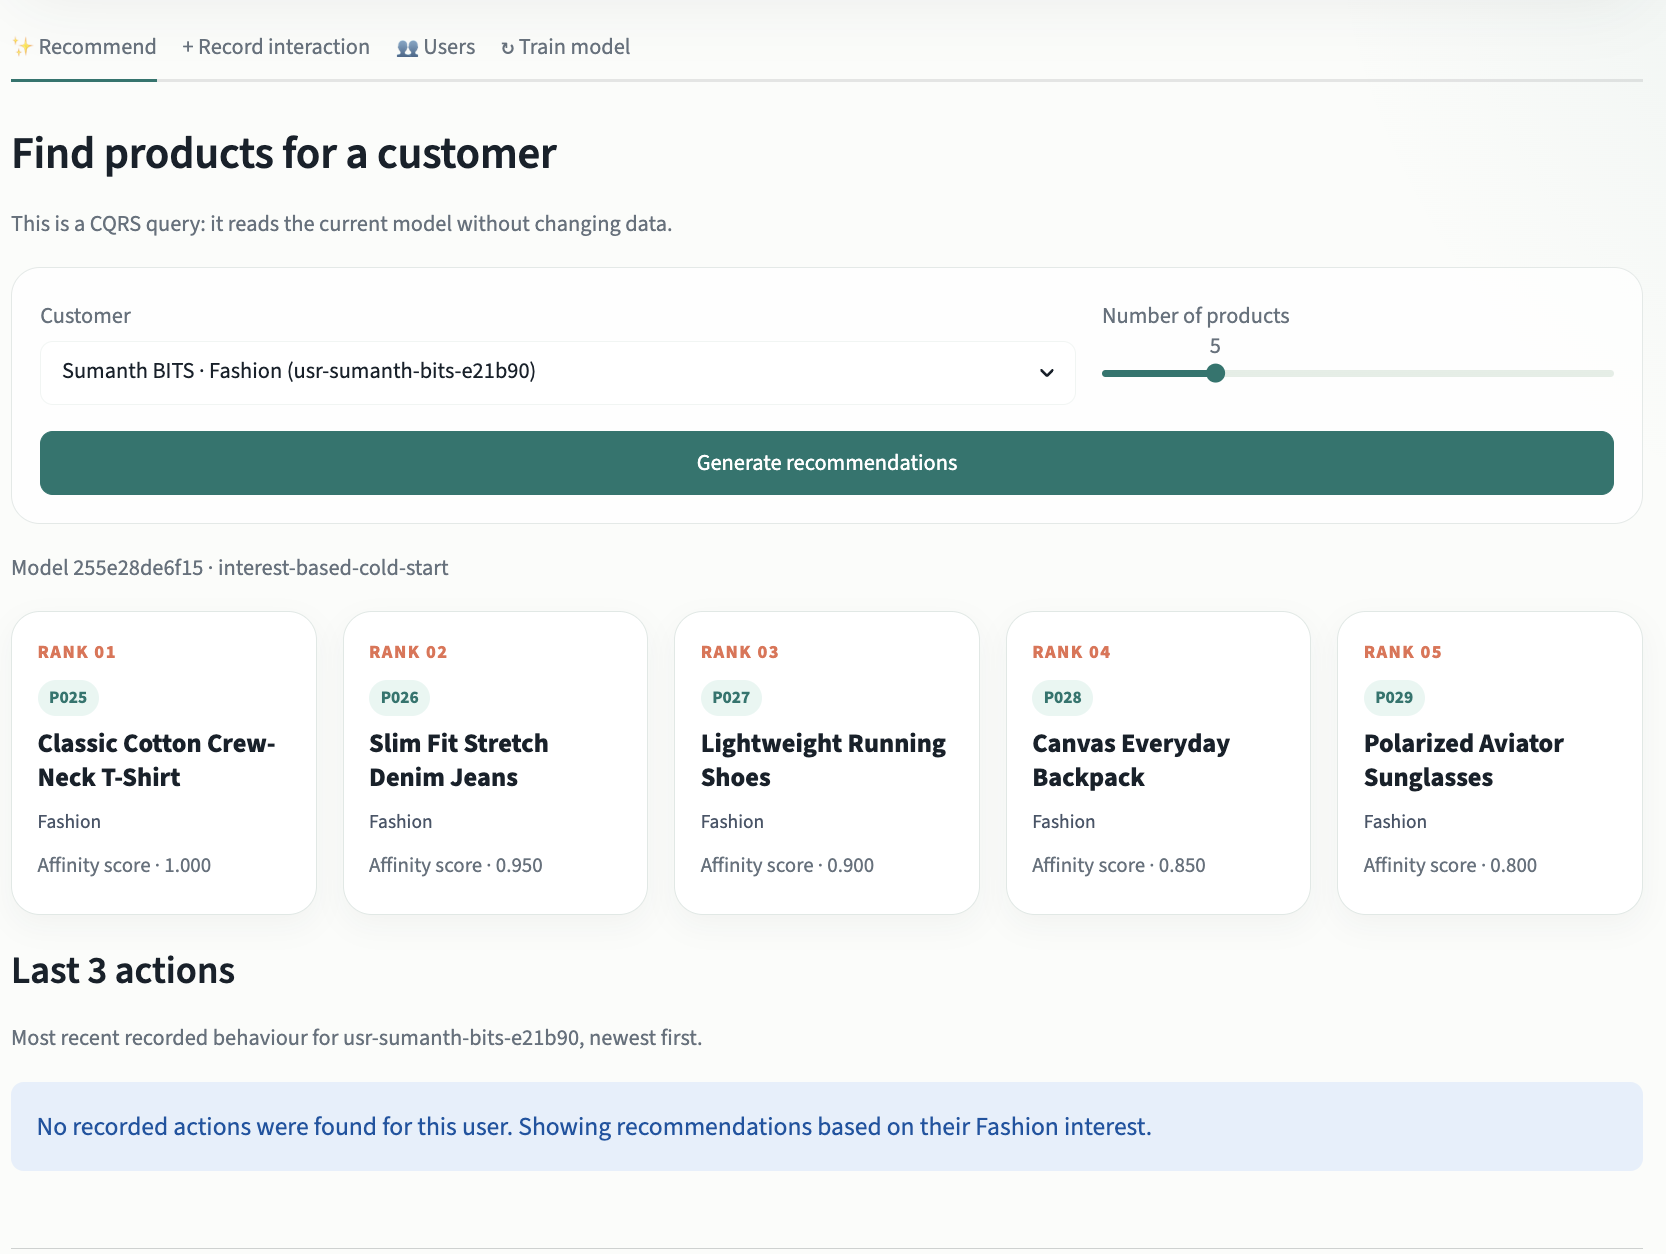

Model-training flow


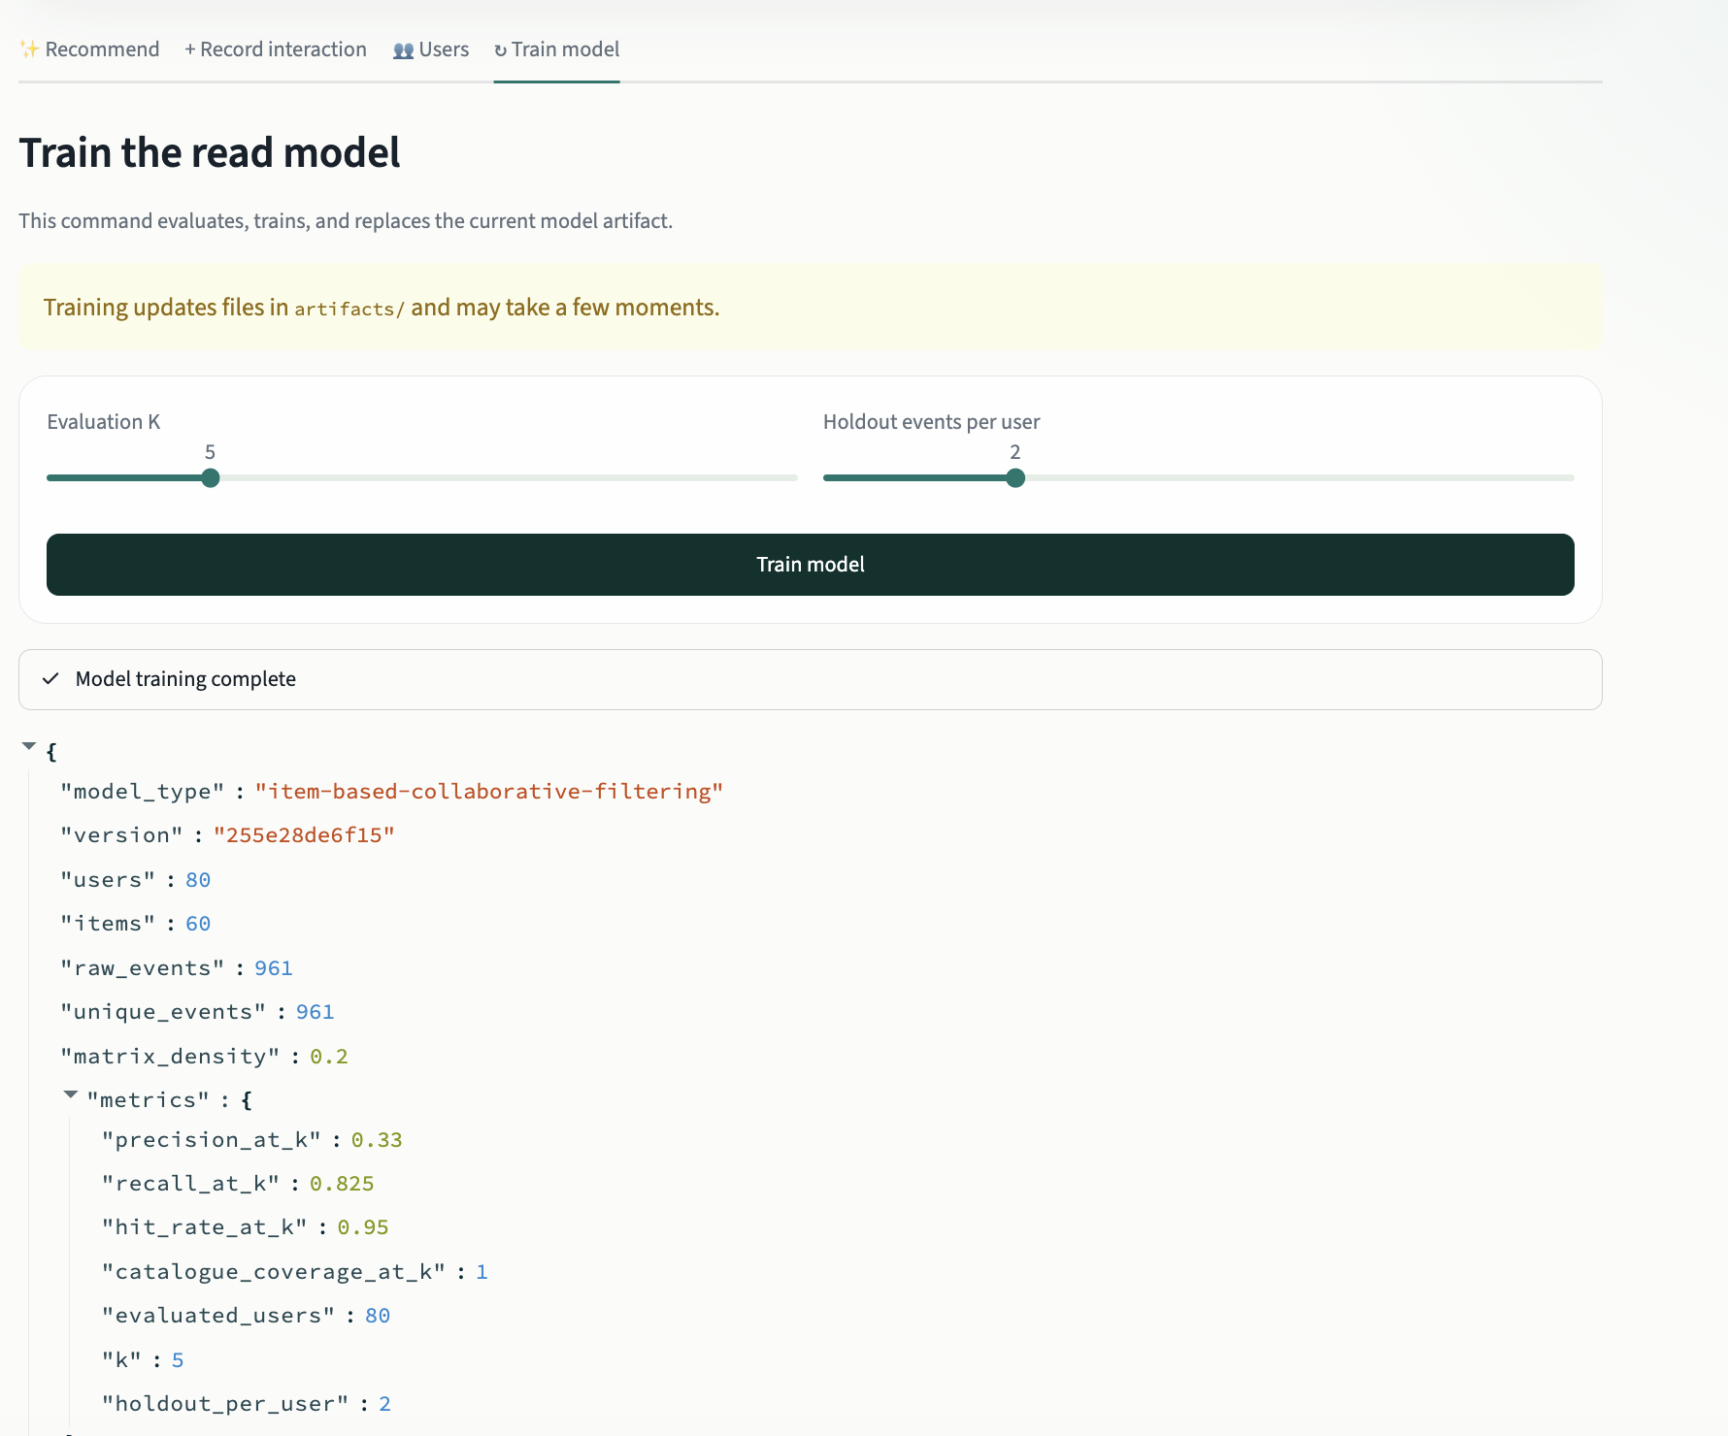

In [6]:

browser_evidence = [
    ("Command Service Swagger UI", ROOT / "evidence" / "command_service_api.png"),
    ("Query Service Swagger UI", ROOT / "evidence" / "query_service_api.png"),
    ("Recommendation and recent-action flow", ROOT / "evidence" / "ui_recommendation_flow.png"),
    ("Interaction command flow", ROOT / "evidence" / "ui_interaction_flow.png"),
    ("Named-user management flow", ROOT / "evidence" / "ui_users_flow.png"),
    ("Interest-based cold-start flow", ROOT / "evidence" / "ui_cold_start_flow.png"),
    ("Model-training flow", ROOT / "evidence" / "ui_training_flow.png"),
]
for title, path in browser_evidence:
    print(title)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"Missing browser capture: {path}")



## 6. Result

The outputs record one end-to-end run: preparation produced the user-item
matrix, offline evaluation calculated the four ranking measures, training wrote
a versioned artifact, and inference returned unseen products for Sumanth. The
browser section covers the two API contracts and the five user-facing flows:
recommendations, interaction recording, user creation, interest-based cold
start, and retraining. The report explains the requirements, diagram
relationships, architecture choices, limitations, and references in more
detail.
